# Is it the rules, or only which cells are there?

Four questions per PCA: where the FOVs fall, whether the cell counts alone put them
in the same places, whether the split survives dropping the composition-linked cell
types, and which cell types those are.


In [1]:
import os
import sys

sys.path.append(os.path.abspath('../..'))   # project root
sys.path.append(os.path.abspath('..'))            # shared helpers, one level up

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

import rule_space_helper as rs
import rule_space_vis as rsv
# Which mining run: data_helper.RESULT_CSV_PATH, shared by every notebook.
# To read a different one, pass its path to dh.load_results / rs.load below.


In [2]:
# --- Settings for this run. Everything else is left at the helper's default. ---
rs.METRIC            = 'Lift'
rs.POSITIVE_ONLY     = False
rs.RULE_MAX_ITEMS    = 2
rs.NO_SELF           = False
rs.MIN_FOV_THRESHOLD = 0.1
rs.SCORE_COL         = 'Pathological score'

data = rs.load()


Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.
Kept 489672 rules at FDR <= 0.05.
Kept 102887 rules that add information.
Kept 101021 rules naming no Unidentified.
Kept 101021 rules (max_items=4, kind=None).


In [3]:
MIN_PER_LABEL = 8      # a group is worth its own PCA only with this many of each label


def rules_inside_one_makeup(data, scope, groups, label, prefix,
                            min_per_label=MIN_PER_LABEL):
    """Do the rules still tell the labels apart among FOVs made of the same things?

    The FOVs have just been split in two by their makeup. This takes the group whose
    two labels are closest to even and fits the rule PCA on those FOVs alone: their
    makeup is alike, so whatever separates them there is the rules' doing and not the
    cell counts'. Evenness beats size: a PCA on 55 against 122 mostly reads the
    bigger label.

    Returns that PCA, or None when neither group holds `min_per_label` of both labels -
    which means the makeup alone already tells the labels apart.
    """
    counts = pd.crosstab(groups, scope.coords.set_index('FOV')[label].reindex(groups.index))
    for name, row in counts.iterrows():
        print(f"  group {name}: " + ", ".join(f"{lab} {int(n)}" for lab, n in row.items()))

    if counts.shape[1] < 2:
        print(f"  only one {label} here - nothing to tell apart, skipped")
        return None
    fewest = counts.min(axis=1)                     # the smaller label in each group
    enough = fewest >= min_per_label
    if not enough.any():
        print(f"  neither group holds {min_per_label}+ of both labels, skipped")
        return None

    even = (fewest / counts.max(axis=1))[enough]     # 1 = the two labels are level
    name = even.idxmax()
    print(f"  group {name} is the most even, {counts.loc[name].min()} against "
          f"{counts.loc[name].max()} - its PCA below")
    inner = rs.run(data, stages=scope.stages, organs=scope.organs,
                   fovs=list(groups.index[groups == name]),
                   prefix=f'{prefix}_group_{name.lower()}', diagnostics=False)
    inner.built_from = f'group {name} alone, alike in makeup'
    rs.scatter(inner, color_by=label, save=True)
    return inner

# 1. All FOVs, both organs

Only the organs here - the stages are asked per organ below.


In [42]:
rs.MIN_FOV_THRESHOLD = 0.01

all_fovs = rs.run(data,
                   prefix='abund_all', diagnostics=False)

rs.MIN_FOV_THRESHOLD = 0.1


both organs, all stages: 267 FOVs x 348 columns  |  PC1 3.1%  PC2 3.0%


### 1a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


both organs, all stages, cell counts: 267 FOVs x 32 columns  |  PC1 40.6%  PC2 20.5%
both organs, all stages: 266 FOVs x 84 columns  |  PC1 9.5%  PC2 6.0%
both organs, all stages, cell counts without Paneth: 267 FOVs x 31 columns  |  PC1 40.9%  PC2 20.6%
both organs, all stages: 267 FOVs x 87 columns  |  PC1 9.3%  PC2 5.9%
both organs, all stages, cell counts without Neuroendocrine: 267 FOVs x 31 columns  |  PC1 40.6%  PC2 20.5%
both organs, all stages: 266 FOVs x 81 columns  |  PC1 9.8%  PC2 5.5%
both organs, all stages, cell counts without Epithelial: 267 FOVs x 31 columns  |  PC1 36.2%  PC2 20.2%
saved summary_downloads\abund_all_panel.pdf


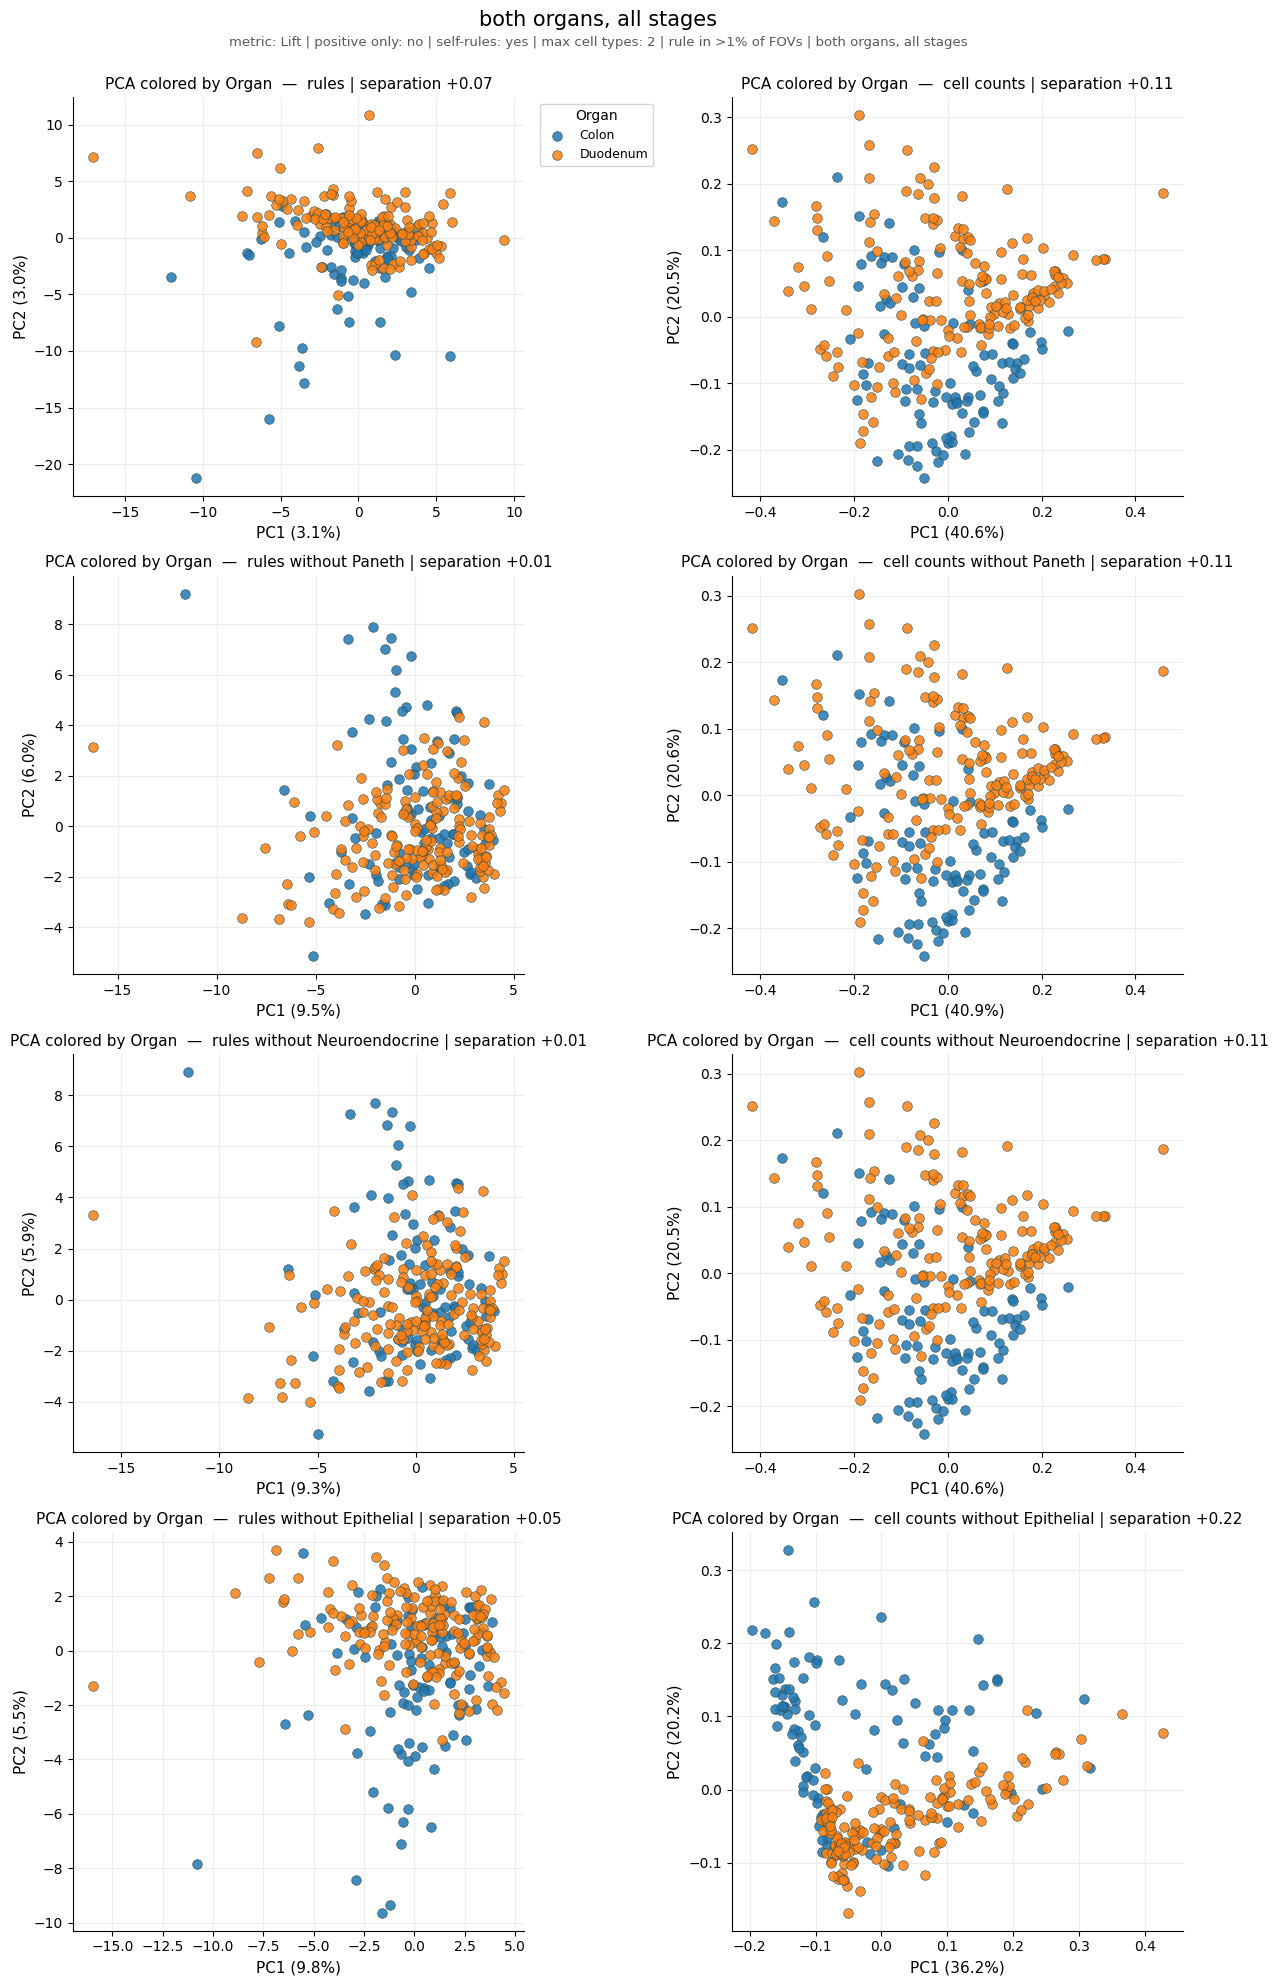

In [43]:
counts  = rs.composition_pca(data, all_fovs)
dropped = rs.leave_one_out(data, all_fovs)   # each row: rules, then cell counts

rs.panel([[all_fovs, counts]] + dropped, color_by='Organ', save='abund_all_panel')


### 1b. Which cell types the components follow


saved summary_downloads\abund_all_abundance_correlation.pdf


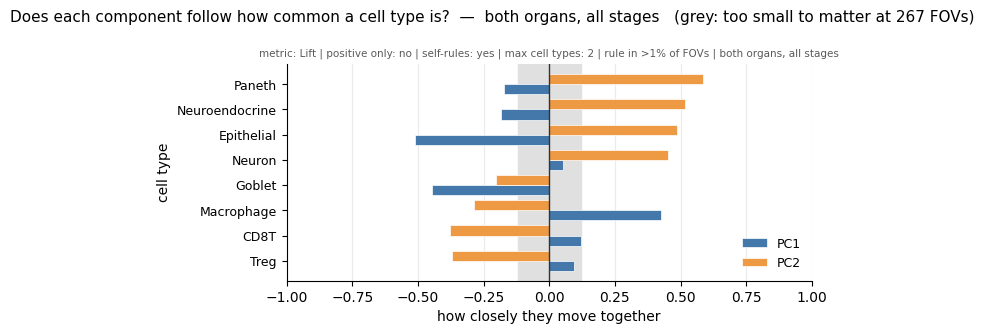

saved summary_downloads\abund_all_abundance_top1.pdf


c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


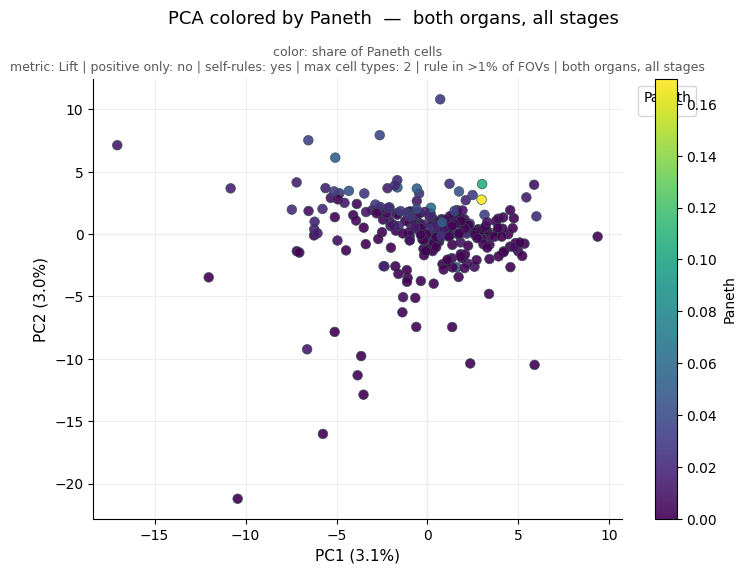

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


saved summary_downloads\abund_all_abundance_top2.pdf


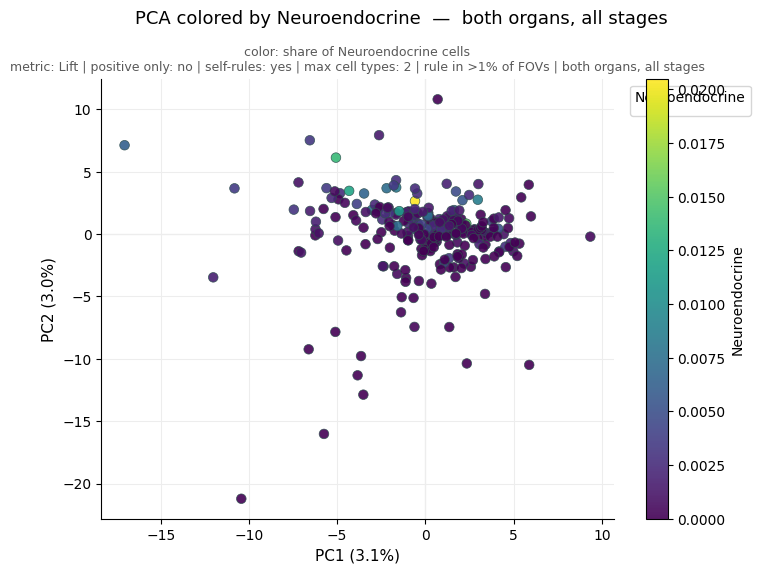

In [44]:
rs.abundance(data, all_fovs, save=True);


# 2. Colon, all stages


In [45]:
colon_all = rs.run(data,
                    organs=['Colon'],
                    prefix='abund_colon', diagnostics=False)


Colon, all stages: 97 FOVs x 83 columns  |  PC1 10.8%  PC2 8.5%


### 2a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Colon, all stages, cell counts: 97 FOVs x 32 columns  |  PC1 38.1%  PC2 25.2%
Colon, all stages: 97 FOVs x 78 columns  |  PC1 10.5%  PC2 8.7%
Colon, all stages, cell counts without Epithelial: 97 FOVs x 31 columns  |  PC1 43.7%  PC2 27.5%
Colon, all stages: 97 FOVs x 62 columns  |  PC1 13.0%  PC2 9.4%
Colon, all stages, cell counts without Muscle: 97 FOVs x 31 columns  |  PC1 35.1%  PC2 30.8%
Colon, all stages: 97 FOVs x 71 columns  |  PC1 11.8%  PC2 9.2%
Colon, all stages, cell counts without CD4T: 97 FOVs x 31 columns  |  PC1 39.4%  PC2 26.1%


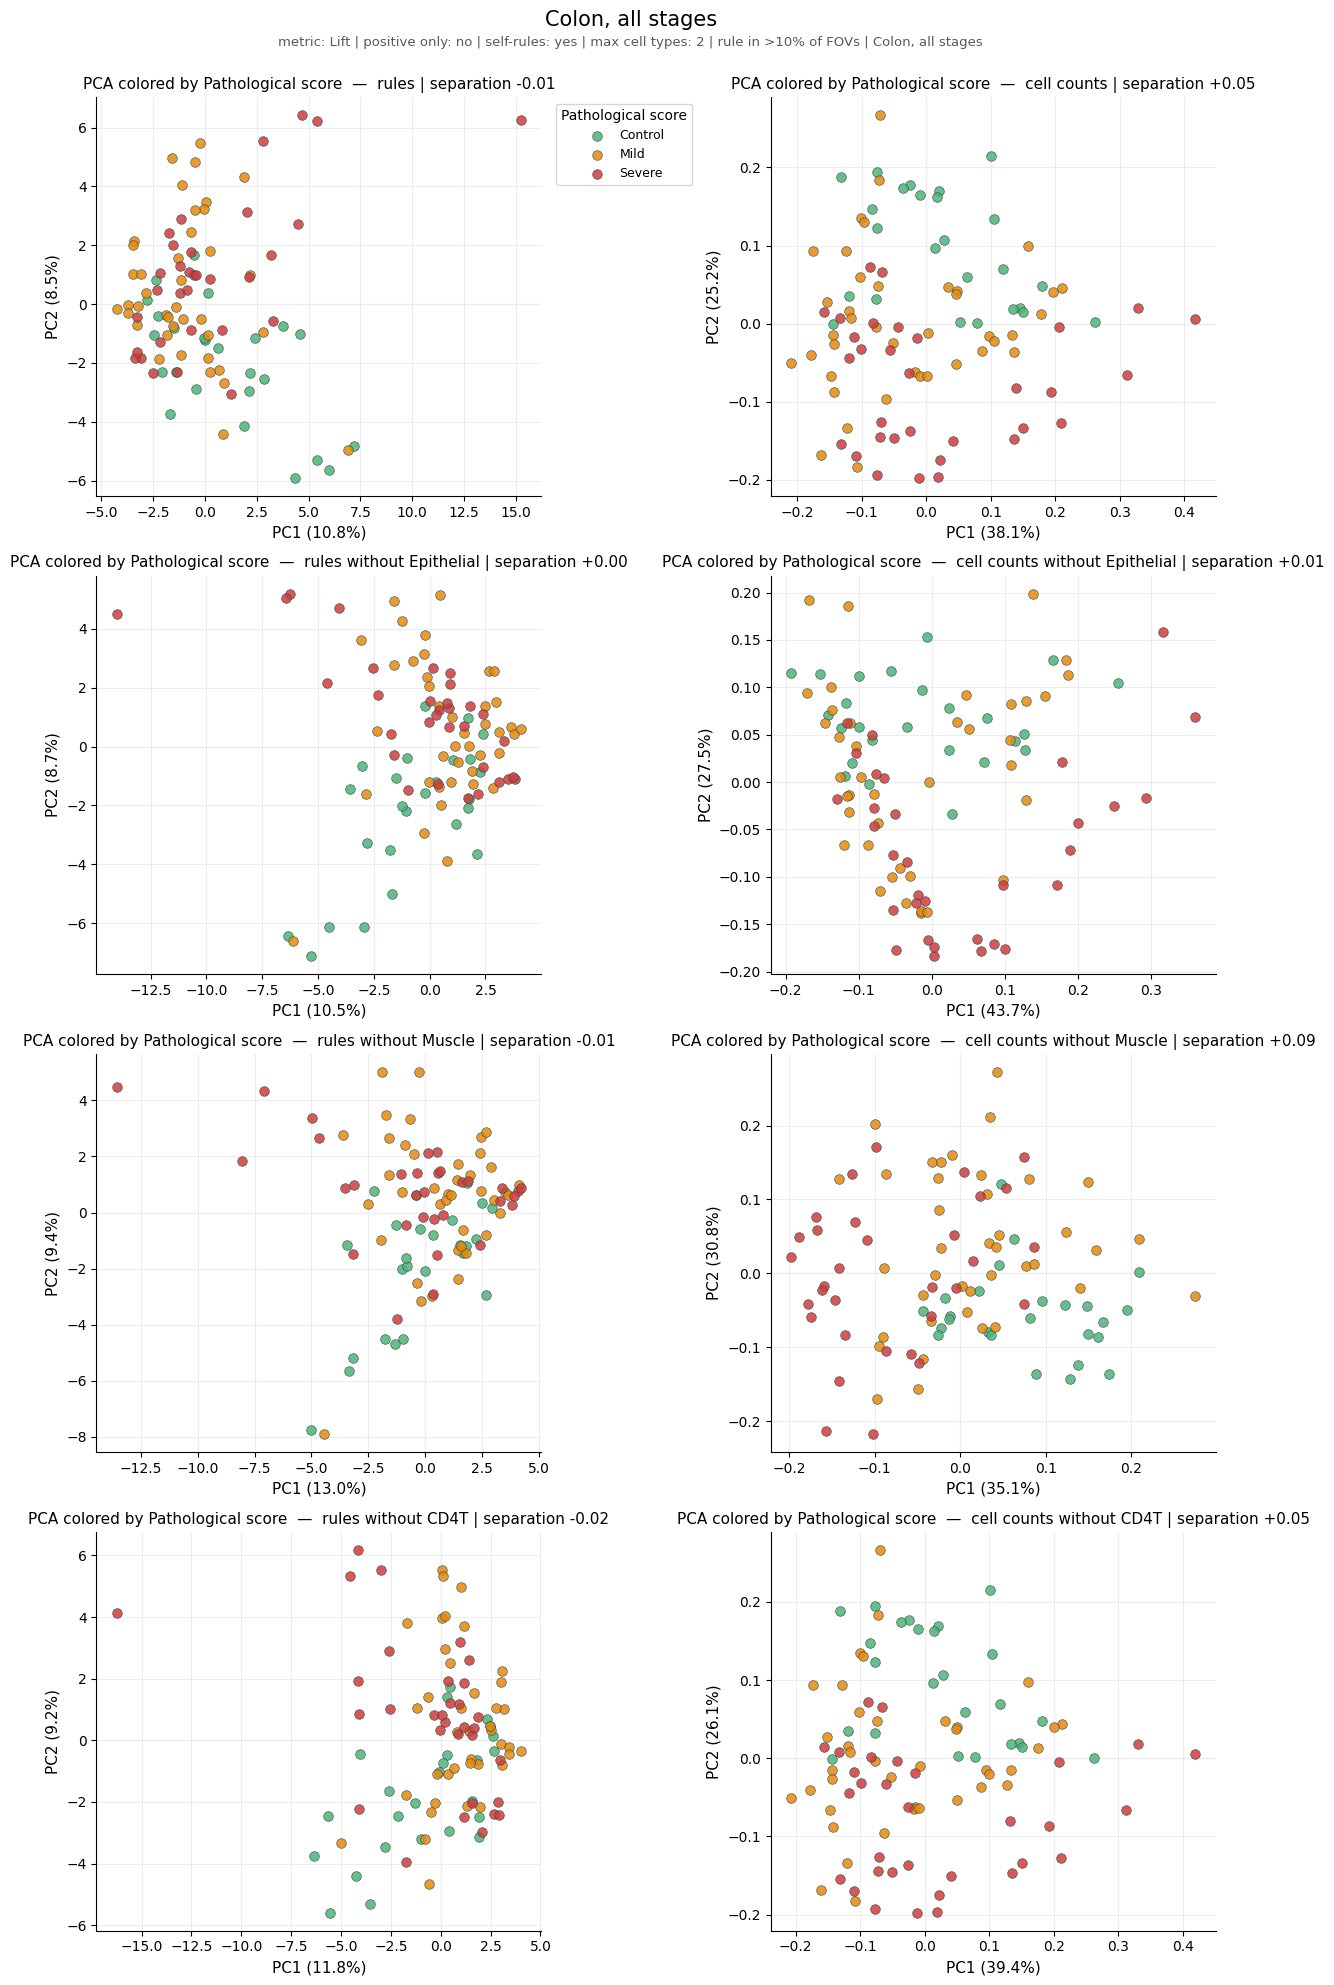

In [46]:
counts  = rs.composition_pca(data, colon_all)
dropped = rs.leave_one_out(data, colon_all)   # each row: rules, then cell counts

rs.panel([[colon_all, counts]] + dropped, save=None)


### 2b. Which cell types the components follow


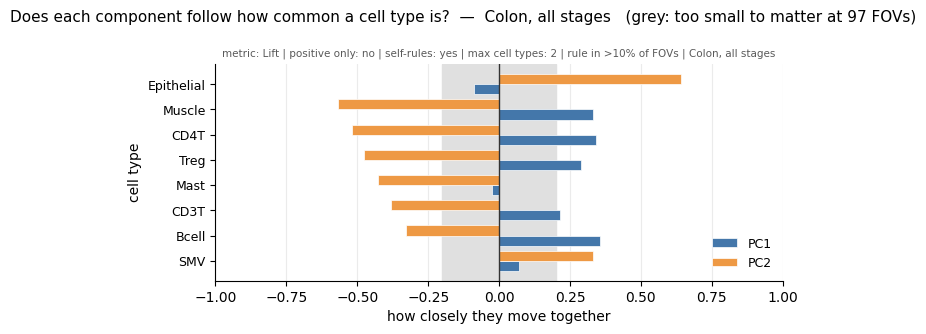

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


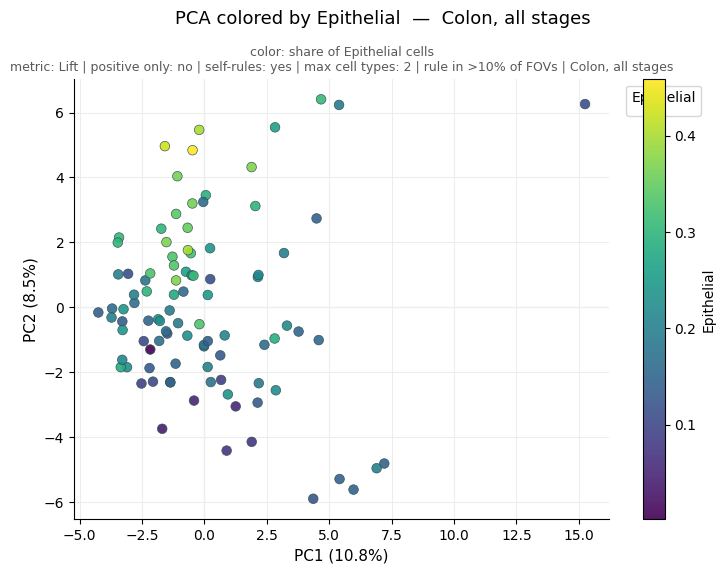

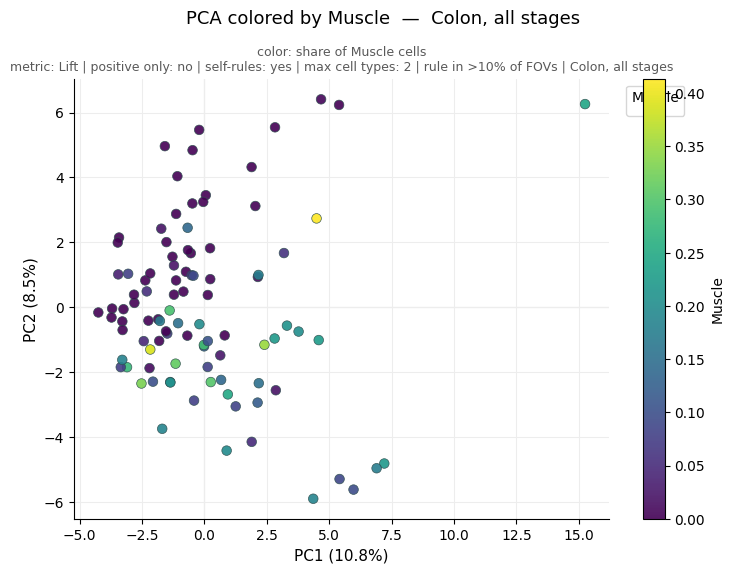

In [9]:
rs.abundance(data, colon_all, save=False);


# 3. Duodenum, all stages


In [10]:
duodenum_all = rs.run(data,
                       organs=['Duodenum'],
                       prefix='abund_duodenum', diagnostics=False)


Duodenum, all stages: 170 FOVs x 86 columns  |  PC1 11.7%  PC2 6.1%


### 3a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Duodenum, all stages, cell counts: 170 FOVs x 32 columns  |  PC1 51.4%  PC2 19.8%
Duodenum, all stages: 169 FOVs x 81 columns  |  PC1 12.2%  PC2 5.5%
Duodenum, all stages, cell counts without Epithelial: 170 FOVs x 31 columns  |  PC1 41.5%  PC2 15.6%
Duodenum, all stages: 170 FOVs x 63 columns  |  PC1 9.3%  PC2 5.7%
Duodenum, all stages, cell counts without Goblet: 170 FOVs x 31 columns  |  PC1 51.4%  PC2 20.1%
Duodenum, all stages: 169 FOVs x 67 columns  |  PC1 14.3%  PC2 6.4%
Duodenum, all stages, cell counts without Muscle: 170 FOVs x 31 columns  |  PC1 59.5%  PC2 9.3%
Duodenum, all stages: 169 FOVs x 70 columns  |  PC1 10.4%  PC2 6.8%
Duodenum, all stages, cell counts without Macrophage: 170 FOVs x 31 columns  |  PC1 53.3%  PC2 19.7%


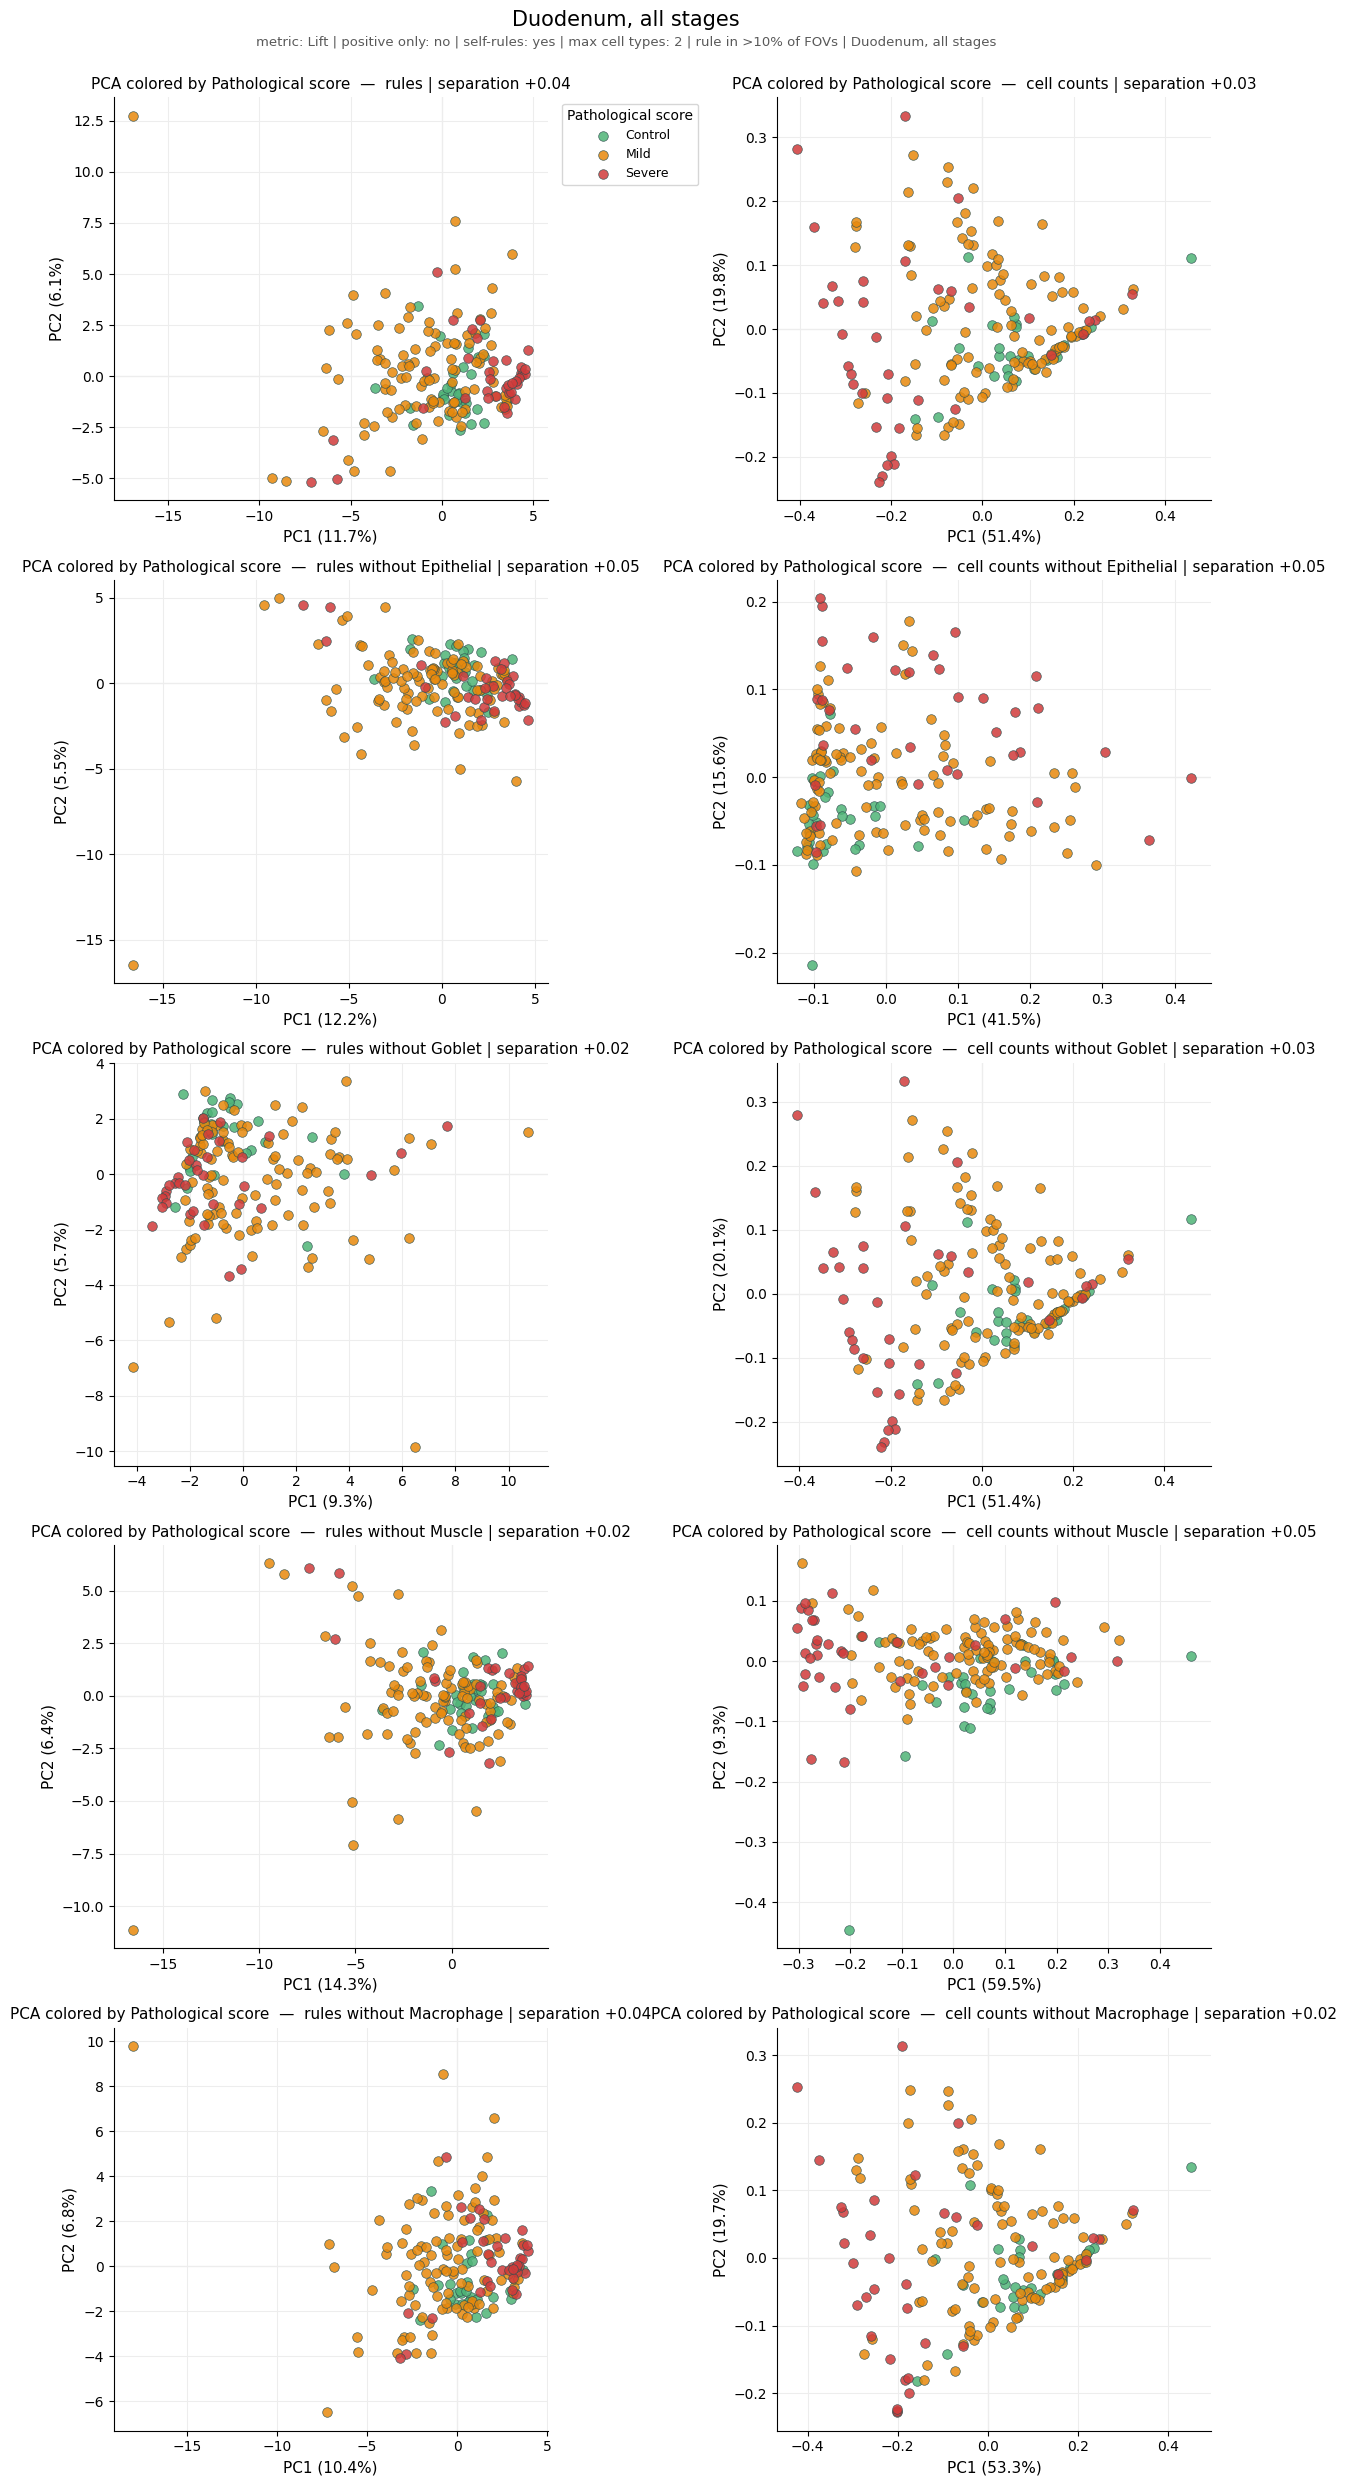

In [11]:
counts  = rs.composition_pca(data, duodenum_all)
dropped = rs.leave_one_out(data, duodenum_all)   # each row: rules, then cell counts

rs.panel([[duodenum_all, counts]] + dropped, save=None)


### 3b. Which cell types the components follow


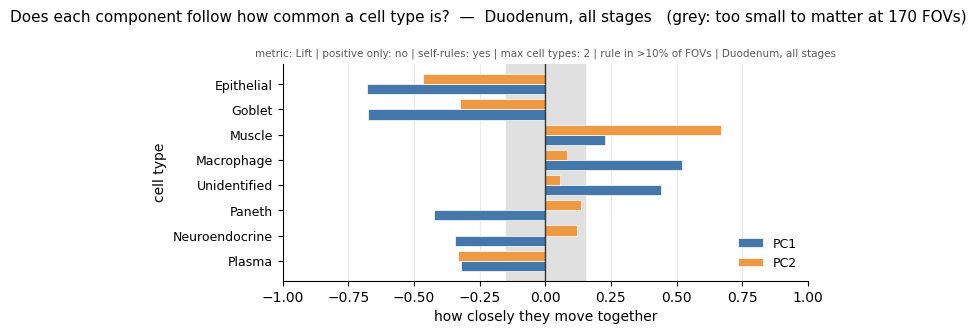

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


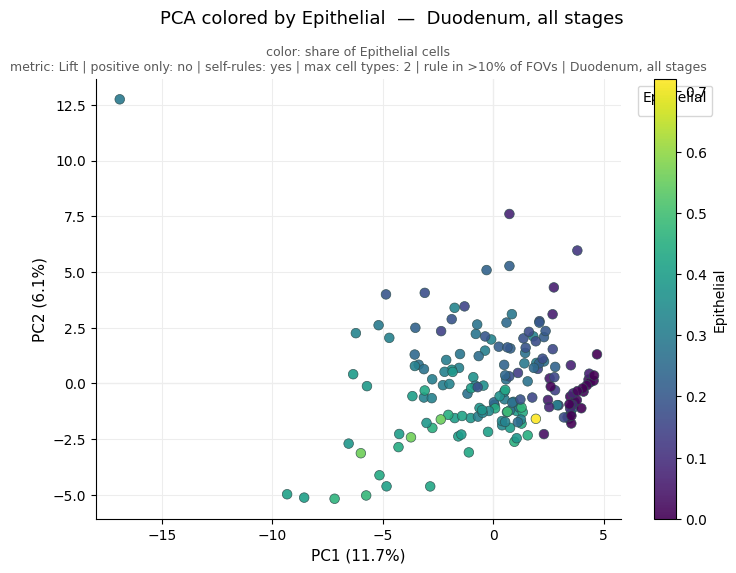

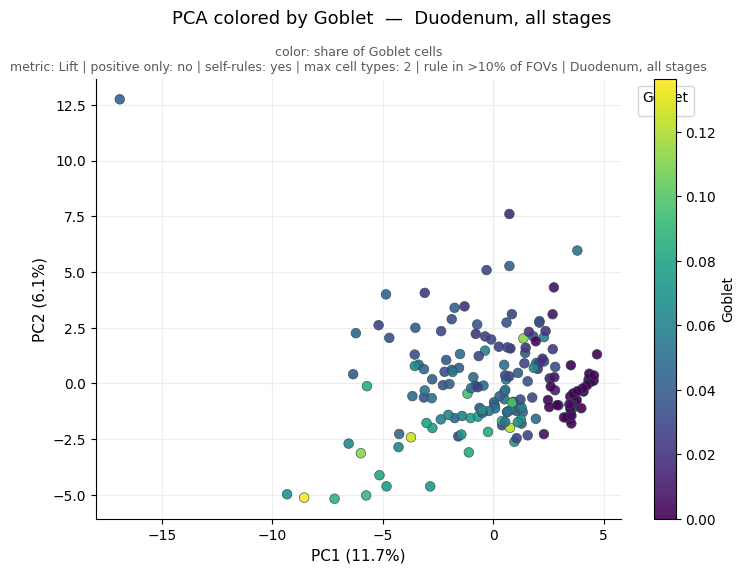

In [12]:
rs.abundance(data, duodenum_all, save=False);


# 4. Colon, Control vs Severe


In [13]:
cs_colon = rs.run(data,
                   stages=['Control', 'Severe'], organs=['Colon'],
                   prefix='abund_cs_colon', diagnostics=False)


Colon, Control vs Severe: 57 FOVs x 100 columns  |  PC1 10.8%  PC2 10.2%


### 4a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Colon, Control vs Severe, cell counts: 57 FOVs x 32 columns  |  PC1 41.3%  PC2 30.7%
Colon, Control vs Severe: 57 FOVs x 96 columns  |  PC1 11.0%  PC2 10.3%
Colon, Control vs Severe, cell counts without Mast: 57 FOVs x 31 columns  |  PC1 41.3%  PC2 30.7%
saved summary_downloads\abund_cs_colon_panel.pdf


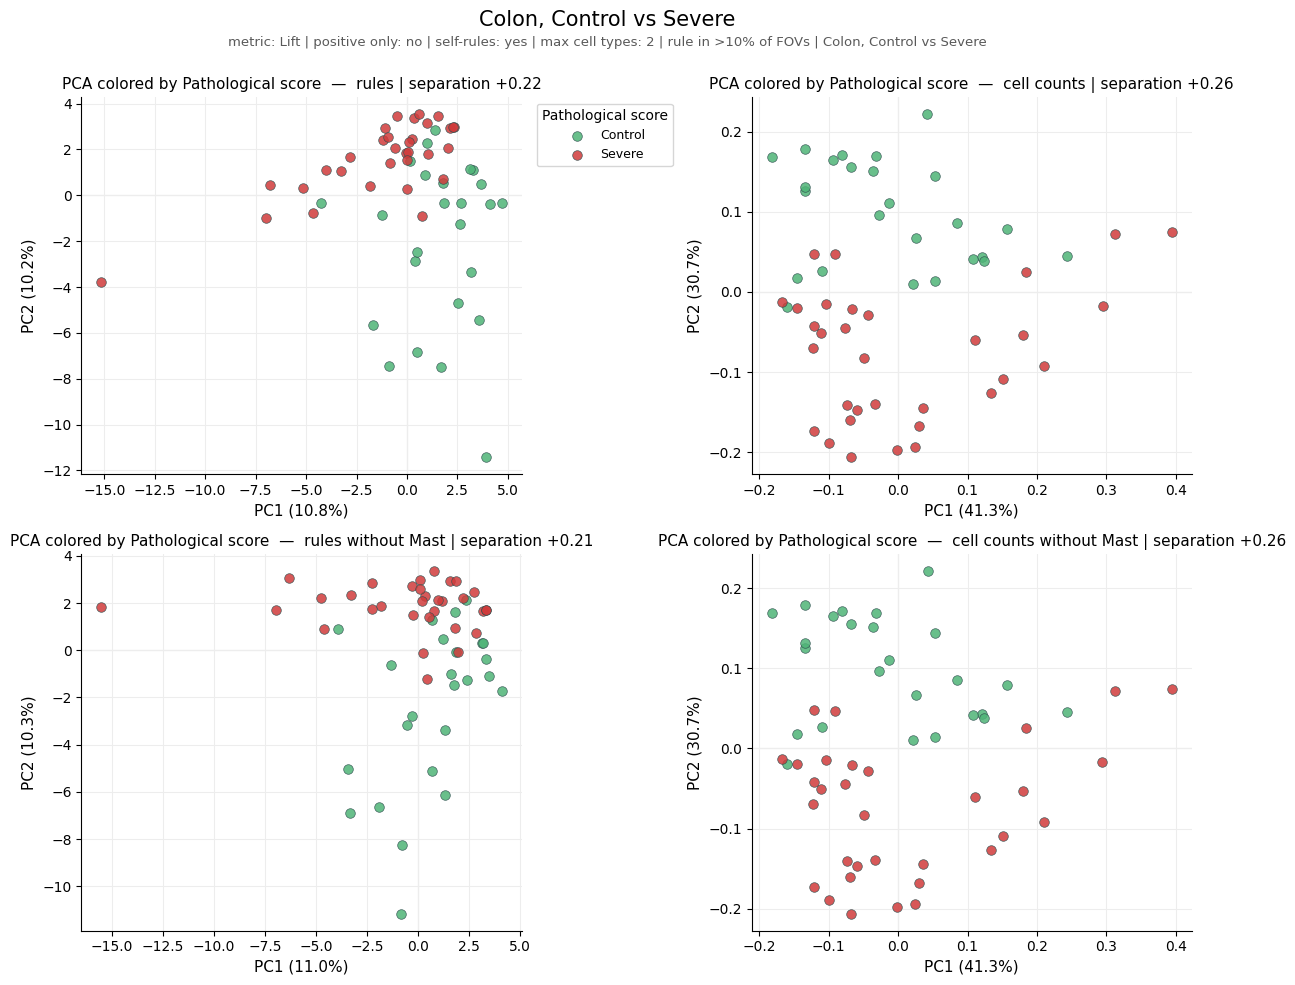

In [14]:
counts  = rs.composition_pca(data, cs_colon)
dropped = rs.leave_one_out(data, cs_colon)   # each row: rules, then cell counts

rs.panel([[cs_colon, counts]] + dropped, save='abund_cs_colon_panel')


### 4b. Which cell types the components follow


saved summary_downloads\abund_cs_colon_abundance_correlation.pdf


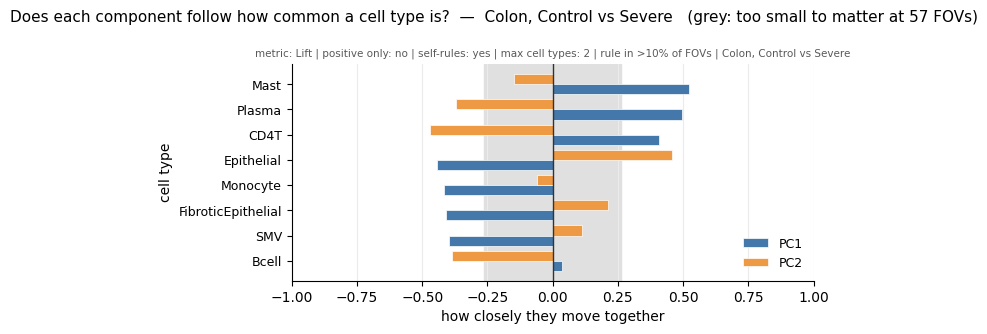

saved summary_downloads\abund_cs_colon_abundance_top1.pdf


c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


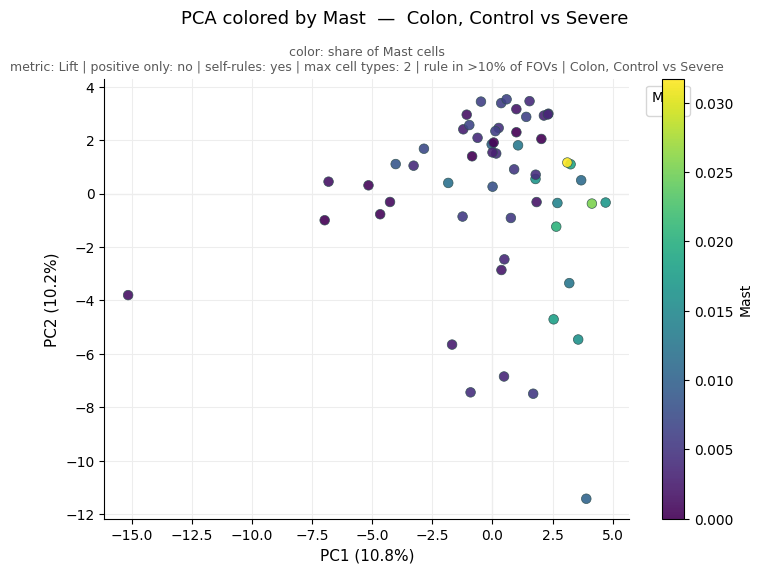

saved summary_downloads\abund_cs_colon_abundance_top2.pdf


c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


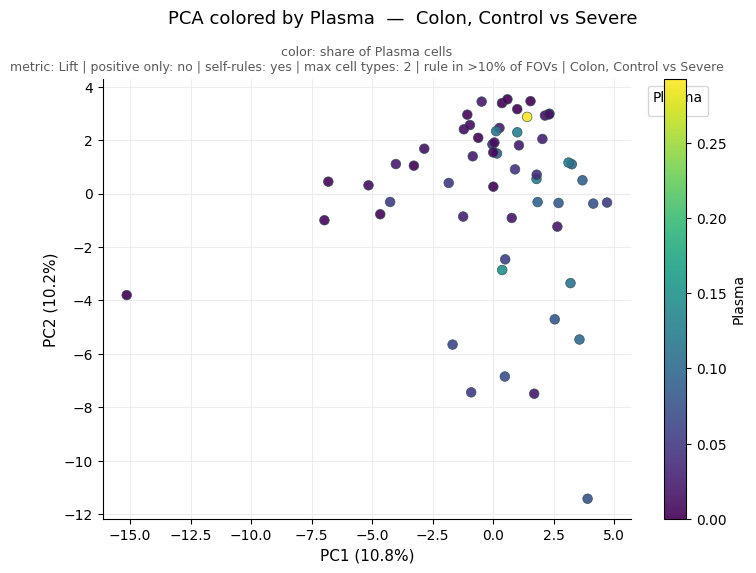

In [15]:
rs.abundance(data, cs_colon, save=True);


# 5. Duodenum, Control vs Severe


In [16]:
cs_duodenum = rs.run(data,
                      stages=['Control', 'Severe'], organs=['Duodenum'],
                      prefix='abund_cs_duodenum', diagnostics=False)


Duodenum, Control vs Severe: 67 FOVs x 74 columns  |  PC1 15.3%  PC2 8.4%


### 5a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Duodenum, Control vs Severe, cell counts: 67 FOVs x 32 columns  |  PC1 57.0%  PC2 16.2%
Duodenum, Control vs Severe: 67 FOVs x 69 columns  |  PC1 15.9%  PC2 7.0%
Duodenum, Control vs Severe, cell counts without Epithelial: 67 FOVs x 31 columns  |  PC1 41.7%  PC2 18.7%
Duodenum, Control vs Severe: 67 FOVs x 53 columns  |  PC1 10.7%  PC2 7.5%
Duodenum, Control vs Severe, cell counts without Goblet: 67 FOVs x 31 columns  |  PC1 56.9%  PC2 16.3%
Duodenum, Control vs Severe: 67 FOVs x 74 columns  |  PC1 15.3%  PC2 8.4%
Duodenum, Control vs Severe, cell counts without FibroticEpithelial: 67 FOVs x 31 columns  |  PC1 57.0%  PC2 16.2%
Duodenum, Control vs Severe: 67 FOVs x 62 columns  |  PC1 16.1%  PC2 8.9%
Duodenum, Control vs Severe, cell counts without Plasma: 67 FOVs x 31 columns  |  PC1 57.8%  PC2 16.4%
Duodenum, Control vs Severe: 67 FOVs x 51 columns  |  PC1 18.8%  PC2 9.2%
Duodenum, Control vs Severe, cell counts without Muscle: 67 FOVs x 31 columns  |  PC1 63.9%  PC2 13.1%
Duodenum, C

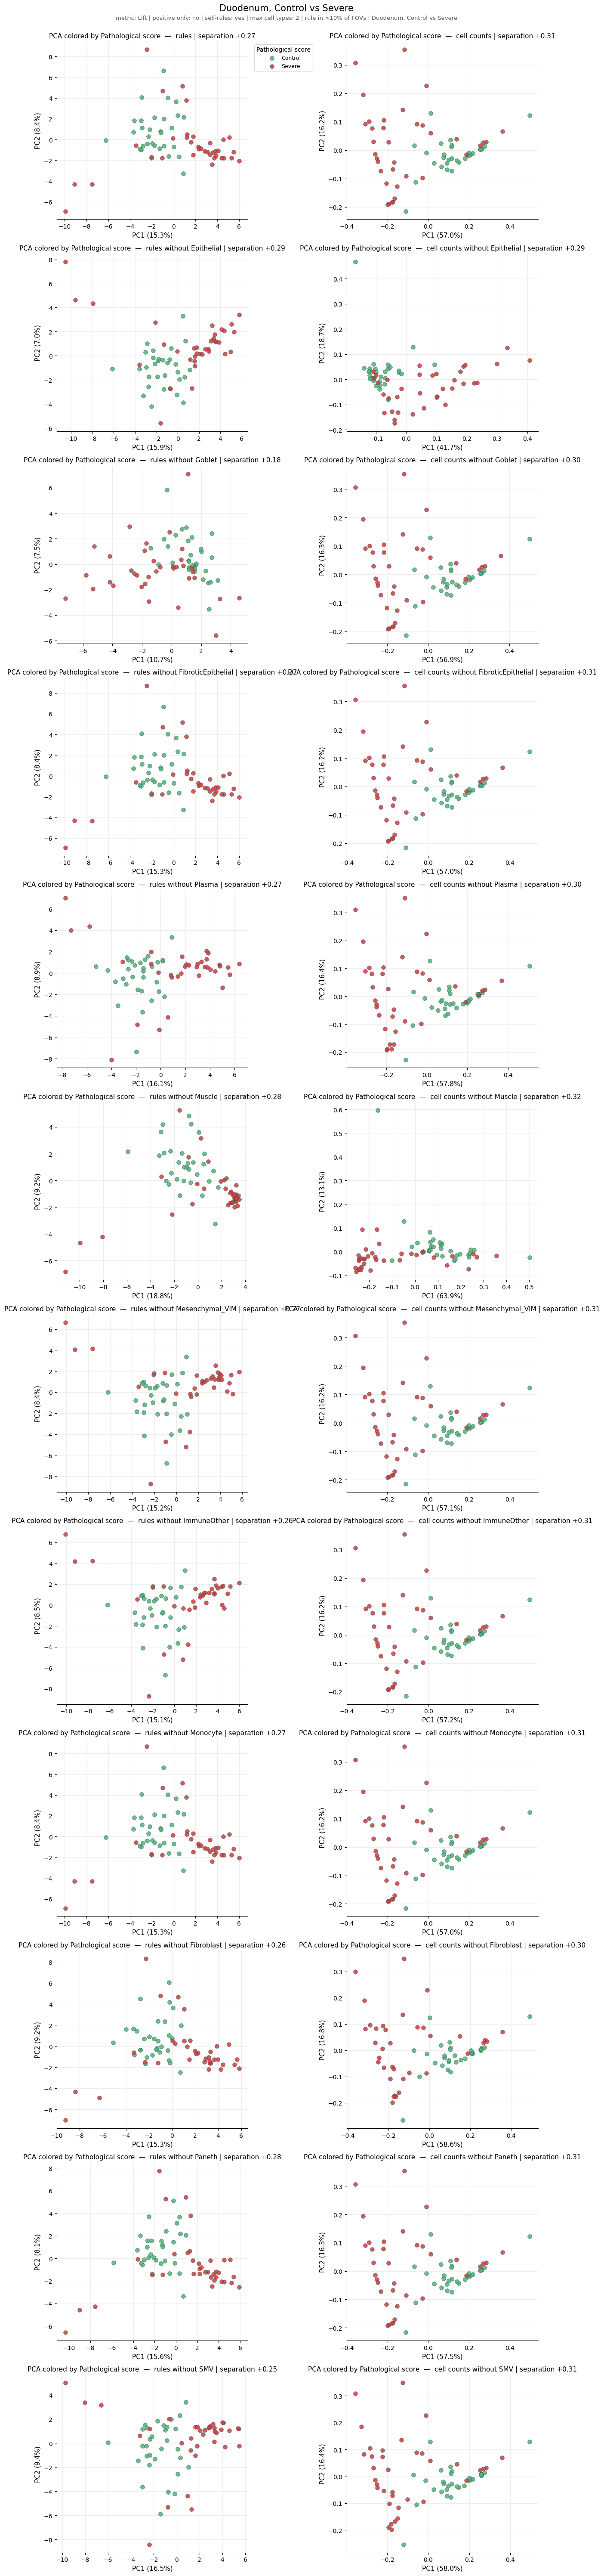

In [17]:
counts  = rs.composition_pca(data, cs_duodenum)
dropped = rs.leave_one_out(data, cs_duodenum)   # each row: rules, then cell counts

rs.panel([[cs_duodenum, counts]] + dropped, save='abund_cs_duodenum_panel')


### 5b. Which cell types the components follow


saved summary_downloads\abund_cs_duodenum_abundance_correlation.pdf


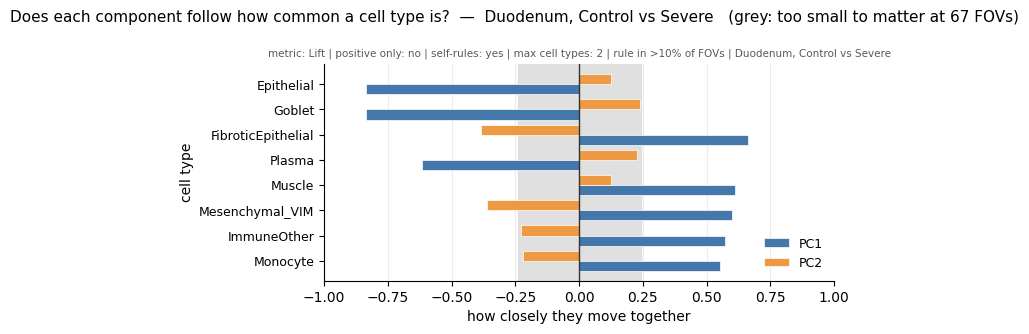

saved summary_downloads\abund_cs_duodenum_abundance_top1.pdf


c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


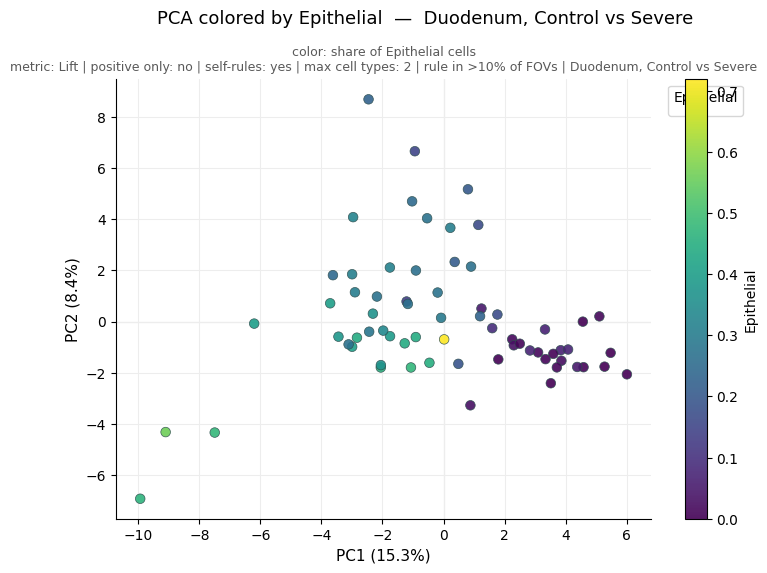

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


saved summary_downloads\abund_cs_duodenum_abundance_top2.pdf


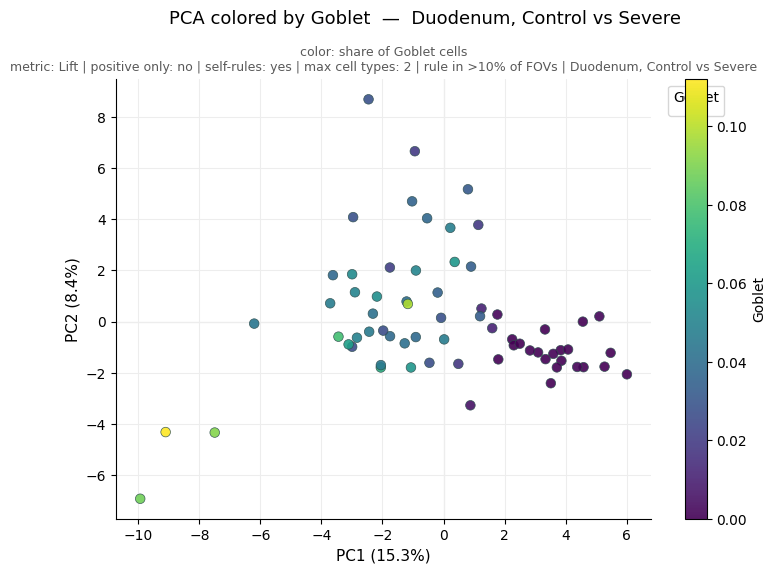

In [18]:
rs.abundance(data, cs_duodenum, save=True);


# 6. Colon, Mild vs Severe


In [19]:
ms_colon = rs.run(data,
                   stages=['Mild', 'Severe'], organs=['Colon'],
                   prefix='abund_ms_colon', diagnostics=False)


Colon, Mild vs Severe: 72 FOVs x 73 columns  |  PC1 12.4%  PC2 9.4%


### 6a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Colon, Mild vs Severe, cell counts: 72 FOVs x 32 columns  |  PC1 41.0%  PC2 23.1%
Colon, Mild vs Severe: 72 FOVs x 54 columns  |  PC1 15.3%  PC2 9.7%
Colon, Mild vs Severe, cell counts without Muscle: 72 FOVs x 31 columns  |  PC1 39.8%  PC2 26.4%
Colon, Mild vs Severe: 72 FOVs x 68 columns  |  PC1 12.7%  PC2 8.8%
Colon, Mild vs Severe, cell counts without Epithelial: 72 FOVs x 31 columns  |  PC1 44.5%  PC2 29.1%
Colon, Mild vs Severe: 68 FOVs x 44 columns  |  PC1 13.9%  PC2 11.3%
Colon, Mild vs Severe, cell counts without Goblet: 72 FOVs x 31 columns  |  PC1 46.6%  PC2 24.2%
Colon, Mild vs Severe: 72 FOVs x 72 columns  |  PC1 12.6%  PC2 9.5%
Colon, Mild vs Severe, cell counts without Treg: 72 FOVs x 31 columns  |  PC1 41.4%  PC2 23.3%


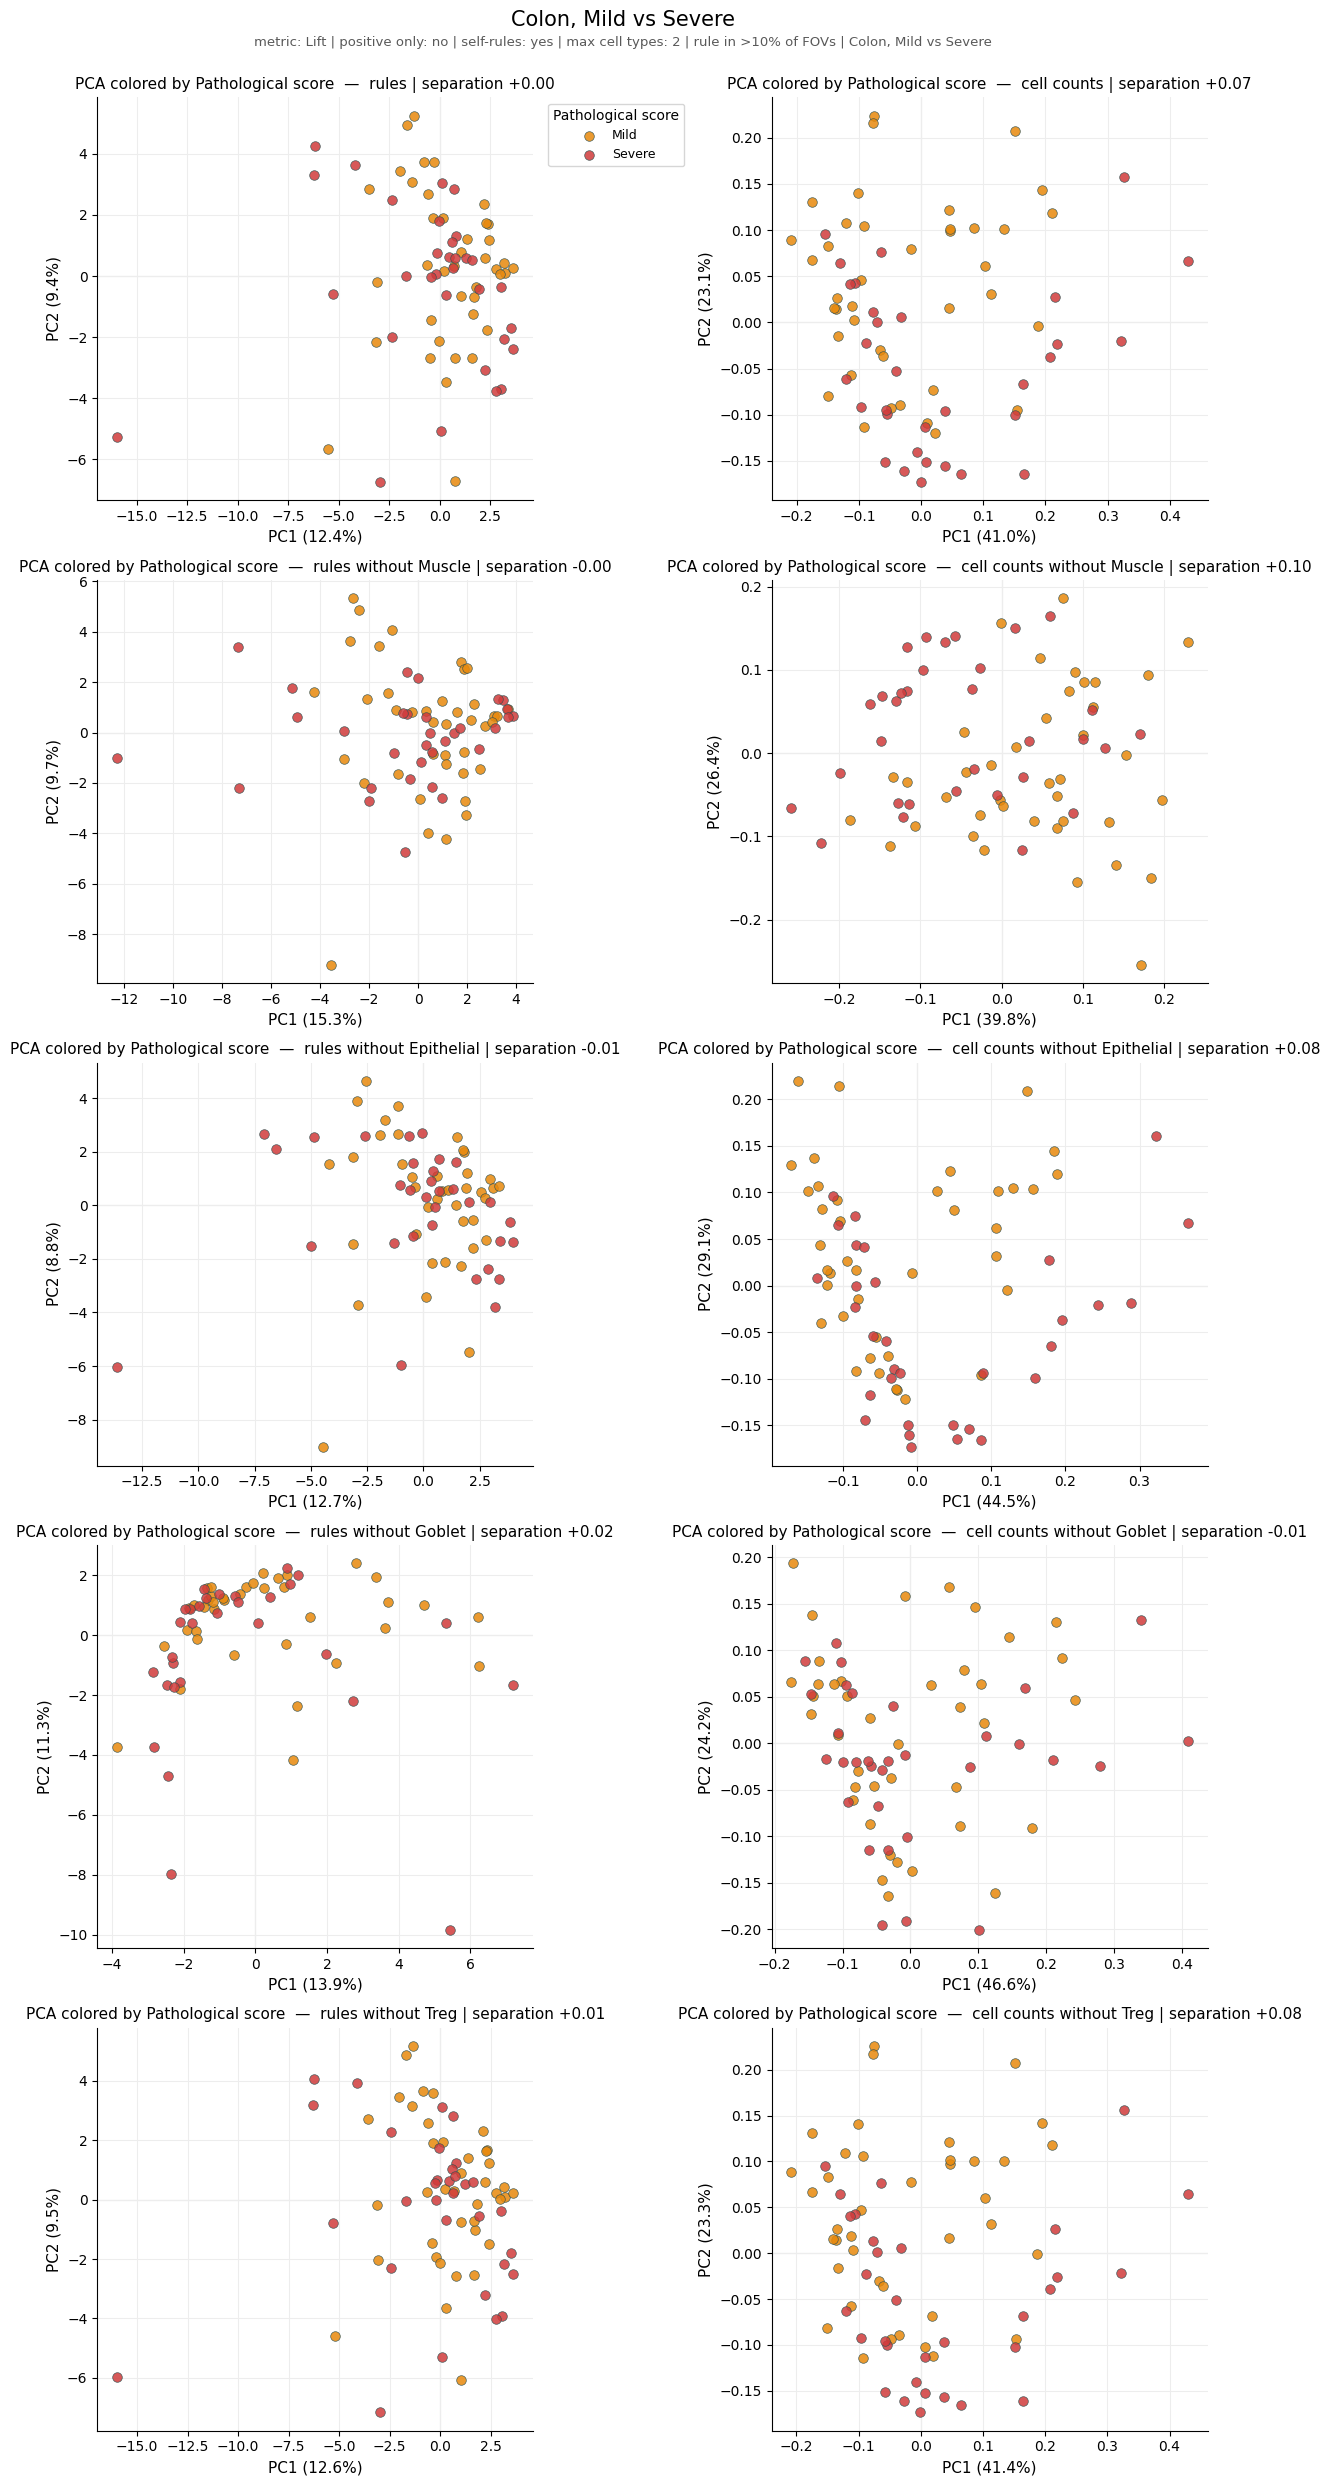

In [20]:
counts  = rs.composition_pca(data, ms_colon)
dropped = rs.leave_one_out(data, ms_colon)   # each row: rules, then cell counts

rs.panel([[ms_colon, counts]] + dropped, save=None)


### 6b. Which cell types the components follow


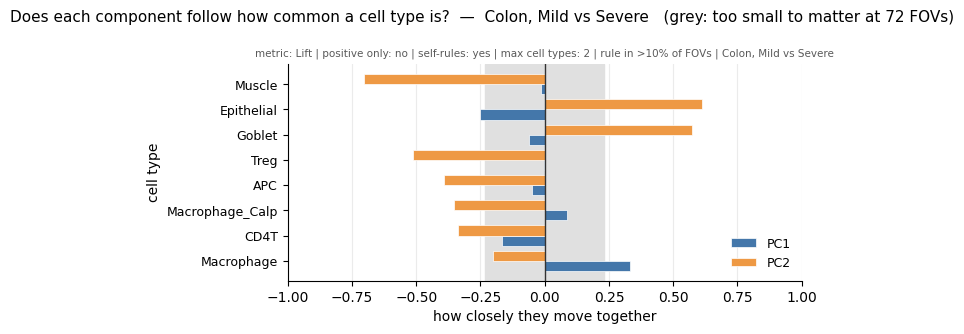

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


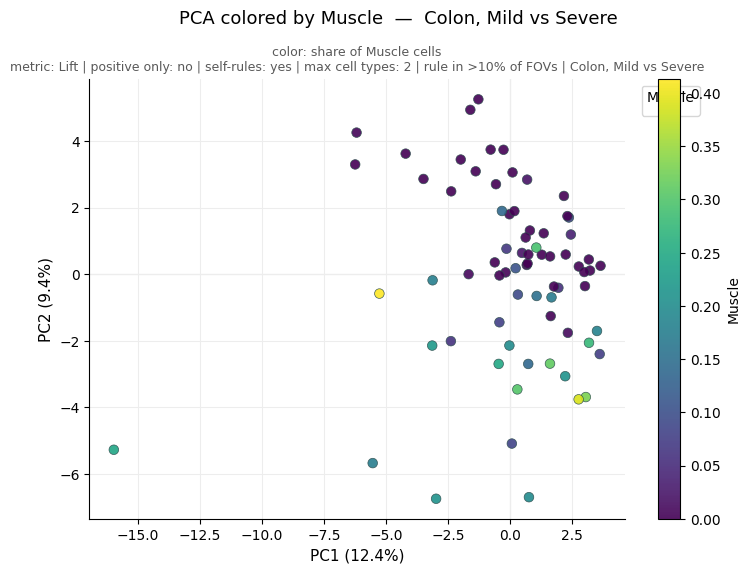

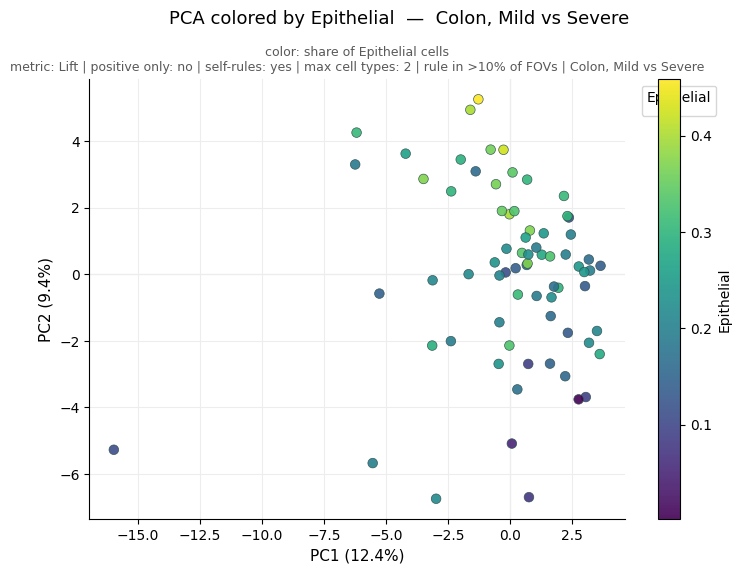

In [21]:
rs.abundance(data, ms_colon, save=False);


# 7. Duodenum, Mild vs Severe


In [22]:
ms_duodenum = rs.run(data,
                      stages=['Mild', 'Severe'], organs=['Duodenum'],
                      prefix='abund_ms_duodenum', diagnostics=False)


Duodenum, Mild vs Severe: 139 FOVs x 96 columns  |  PC1 11.7%  PC2 5.9%


### 7a. The rules, the cell counts, and the rules minus one linked cell type

Top row: where the FOVs fall from their rules, and from their cell counts alone.
If they come apart just as well on the right, the rules are adding nothing.
Below: the same rules again, each time with one composition-linked cell type
left out.


Duodenum, Mild vs Severe, cell counts: 139 FOVs x 32 columns  |  PC1 52.7%  PC2 22.8%
Duodenum, Mild vs Severe: 139 FOVs x 90 columns  |  PC1 12.3%  PC2 5.5%
Duodenum, Mild vs Severe, cell counts without Epithelial: 139 FOVs x 31 columns  |  PC1 45.6%  PC2 16.5%
Duodenum, Mild vs Severe: 139 FOVs x 73 columns  |  PC1 9.3%  PC2 5.8%
Duodenum, Mild vs Severe, cell counts without Goblet: 139 FOVs x 31 columns  |  PC1 52.5%  PC2 23.1%
Duodenum, Mild vs Severe: 138 FOVs x 78 columns  |  PC1 10.3%  PC2 6.6%
Duodenum, Mild vs Severe, cell counts without Macrophage: 139 FOVs x 31 columns  |  PC1 54.8%  PC2 22.7%
Duodenum, Mild vs Severe: 138 FOVs x 75 columns  |  PC1 14.1%  PC2 6.7%
Duodenum, Mild vs Severe, cell counts without Muscle: 139 FOVs x 31 columns  |  PC1 63.5%  PC2 8.6%


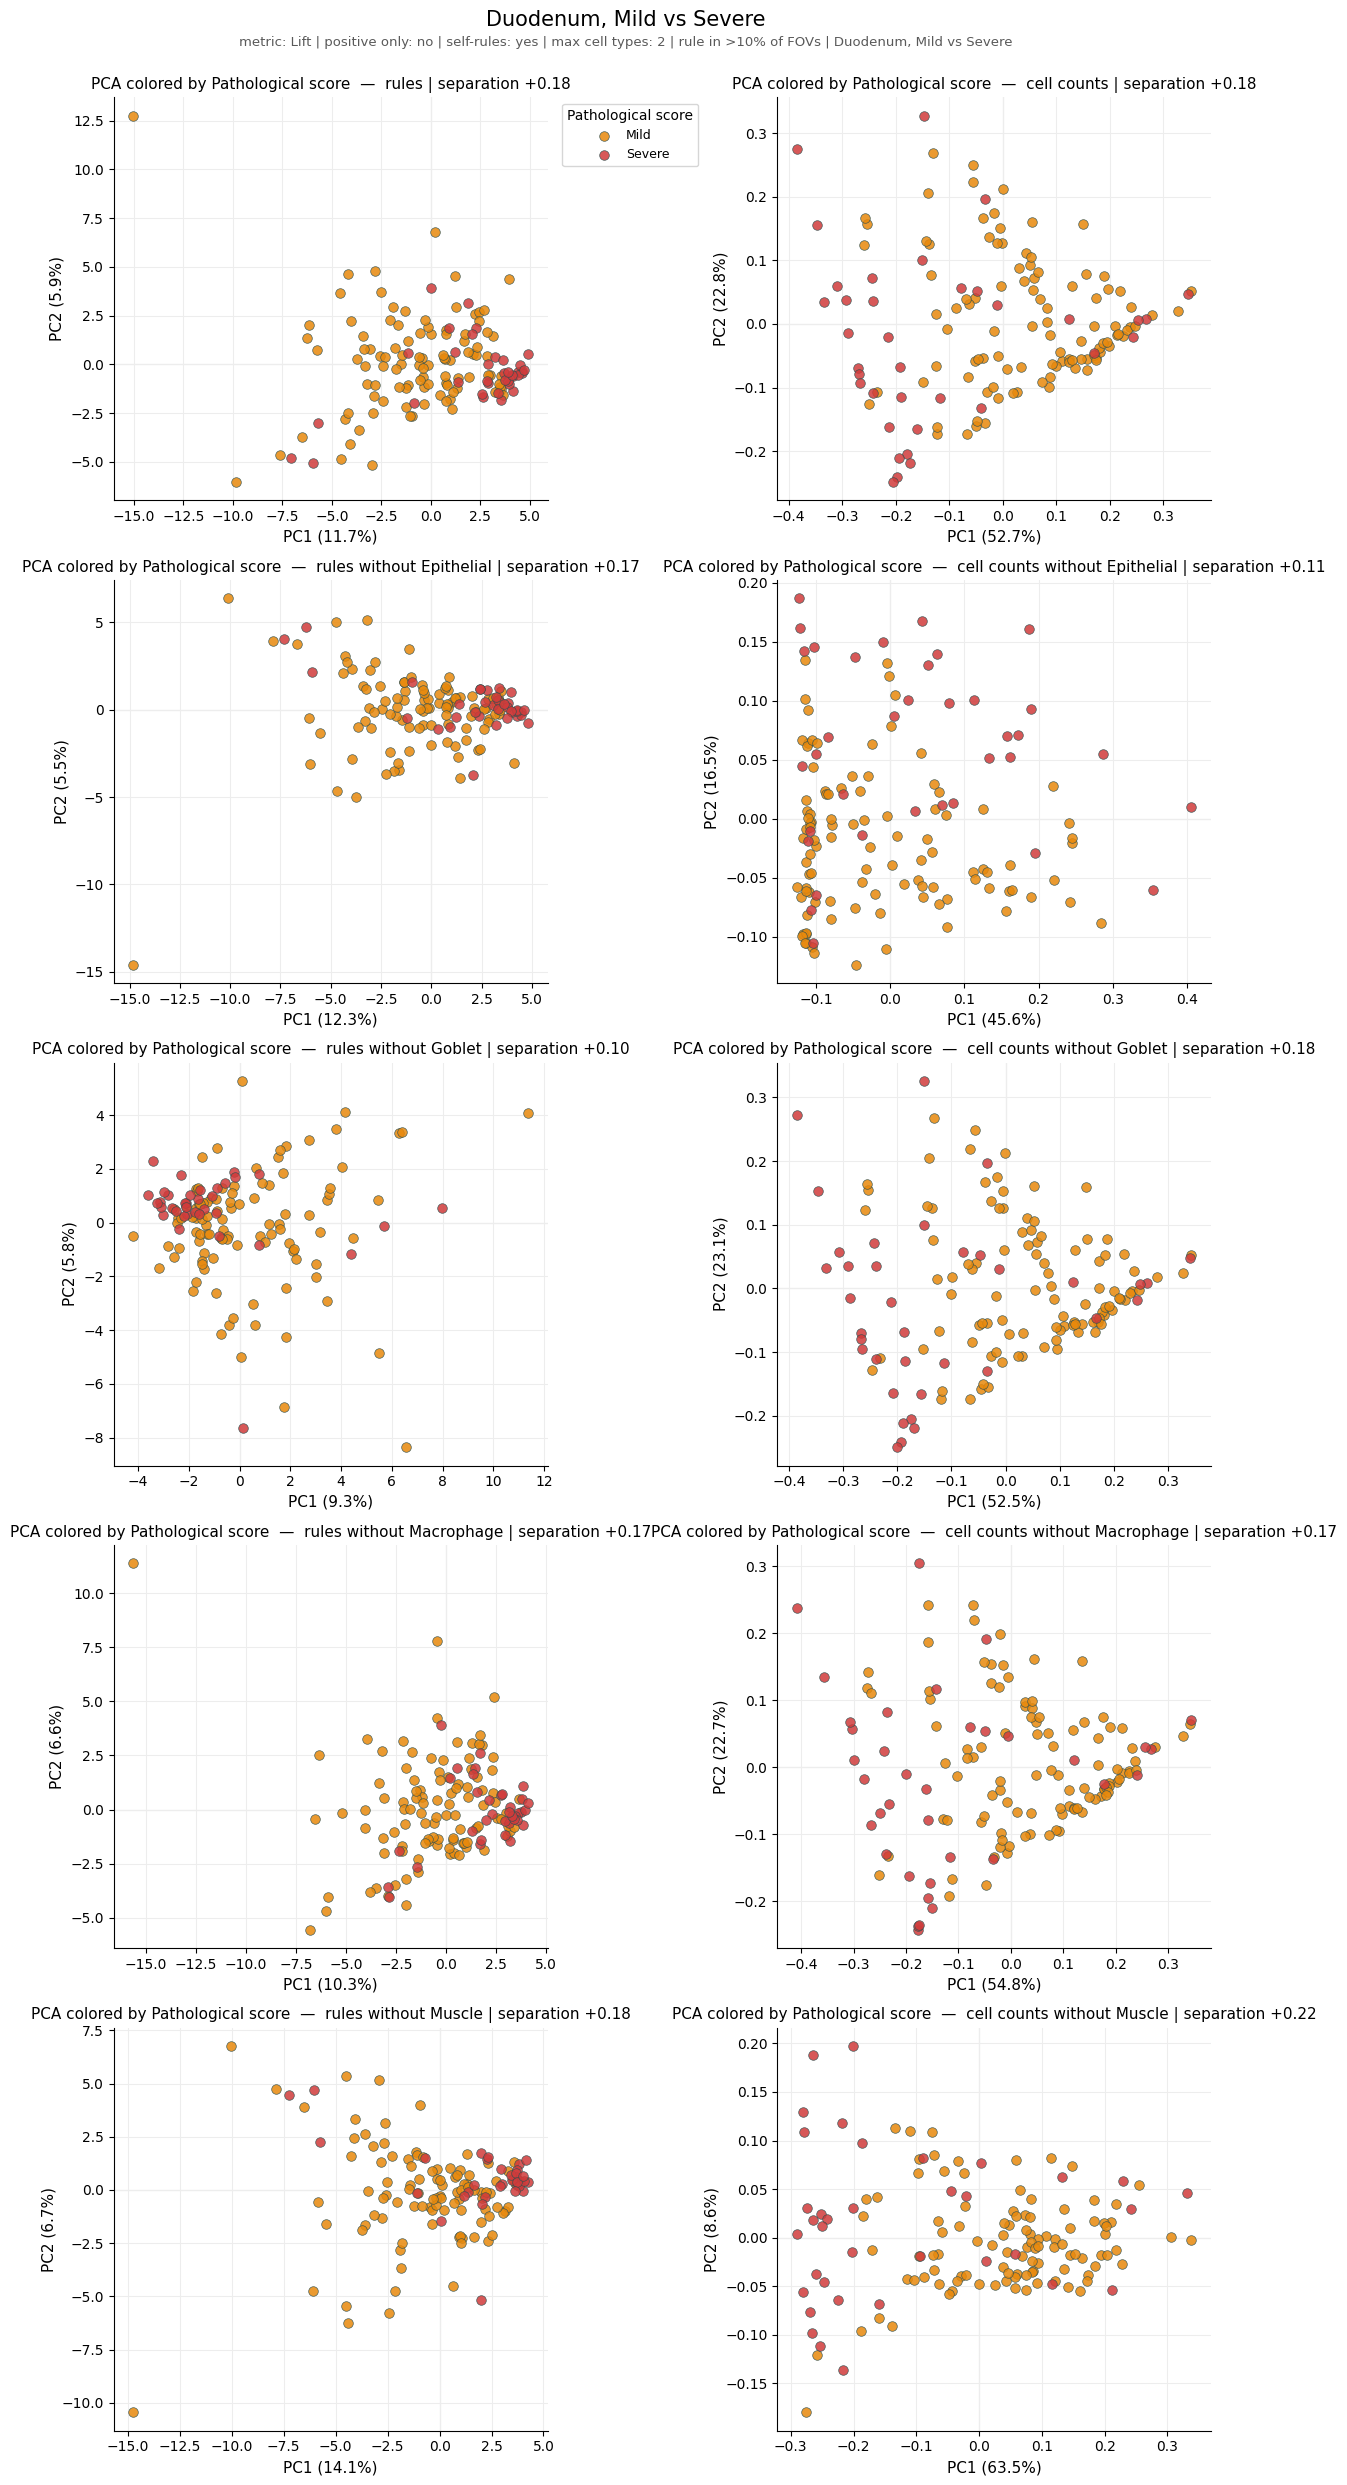

In [23]:
counts  = rs.composition_pca(data, ms_duodenum)
dropped = rs.leave_one_out(data, ms_duodenum)   # each row: rules, then cell counts

rs.panel([[ms_duodenum, counts]] + dropped, save=None)


### 7b. Which cell types the components follow


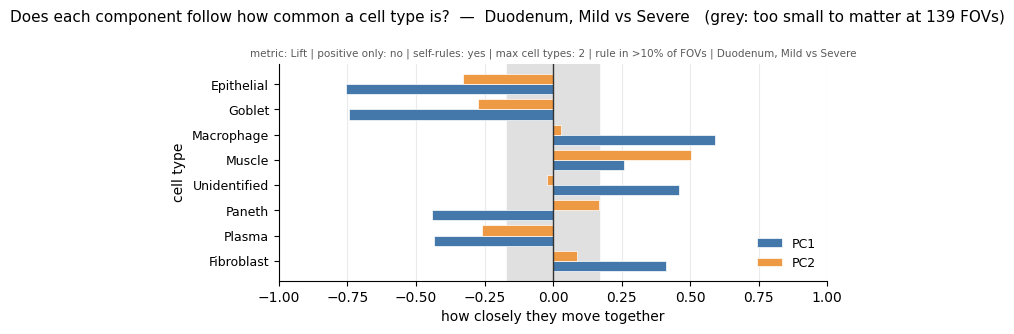

c:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\rule_space\rule_space_vis.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=color_by, fontsize=9, title_fontsize=10,


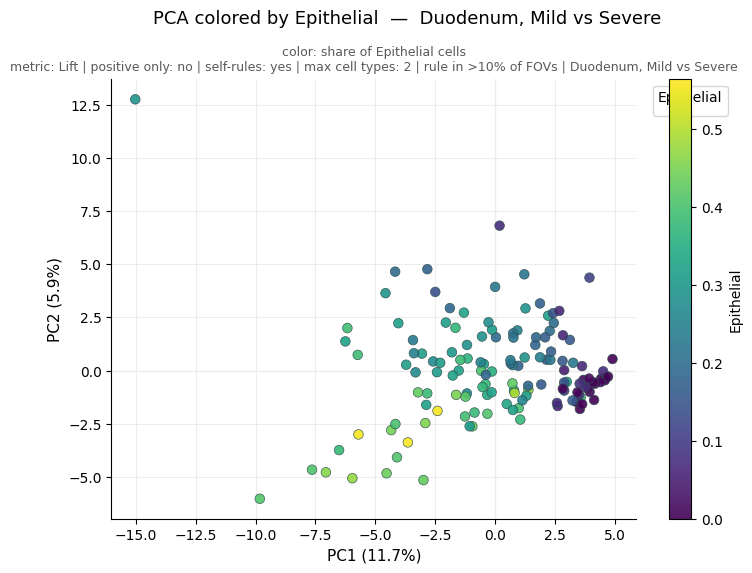

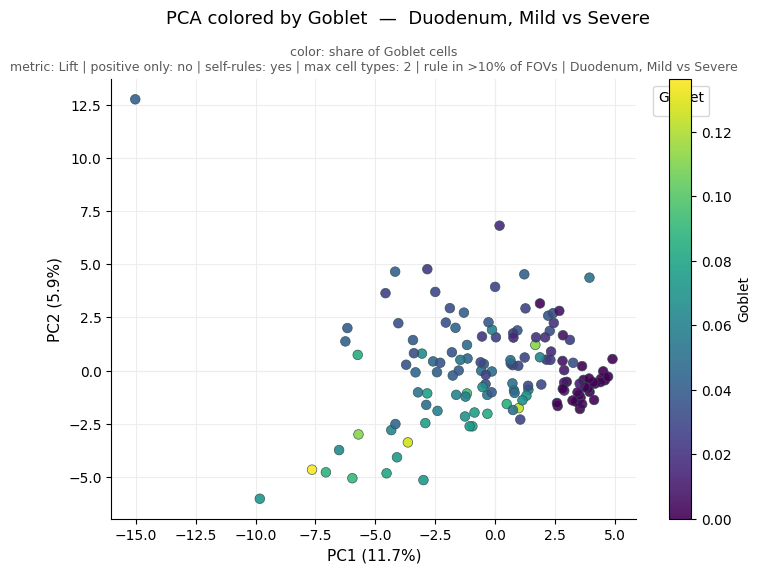

In [24]:
rs.abundance(data, ms_duodenum, save=False);


# 8. Same cells, different arrangement?

The FOVs are split in two by what they are made of - only the cell types this
PCA's components follow. If a group holds just one label, the cell counts alone
already separate those FOVs. If a group holds both, the rules can still be asked
whether they tell them apart with the composition held roughly fixed.


In [25]:
def composition_groups(data, scope, label, save=None):
    """Split the FOVs in two by how much they hold of the cell types tied to this PCA.

    Clustering is on the square root of each share: raw shares let a cell type at 20%
    drown one at 3%, while standardising would give one at 0.1% an equal vote. The
    square root sits between the two.
    """
    cells = rs.linked_cells(data, scope)
    shares = data.fractions.reindex(scope.coords['FOV'])[cells]
    group = pd.Series(KMeans(n_clusters=2, n_init=10, random_state=0)
                      .fit_predict(np.sqrt(shares)), index=shares.index).map({0: 'A', 1: 'B'})
    table = pd.crosstab(group.rename('group'), scope.coords[label].values)
    rsv.plot_composition_split(table, shares.groupby(group).mean(), scope.label, label, save)
    return group, table

def composition_figures(data, scope, group, label, prefix):
    """The FOVs behind the groups: what each is made of, and every cell type at once."""
    cells = rs.linked_cells(data, scope)
    shares = data.fractions.reindex(scope.coords['FOV'])[cells] * 100
    order = shares.assign(_g=group).sort_values(['_g', cells[0]]).index

    frac = data.fractions.reindex(order)
    z = (frac - frac.mean()) / frac.std().replace(0, np.nan)

    # Cell types ordered by how far apart the two groups are, so the ones that tell
    # them apart gather at the two ends and the rest fall into the middle.
    per_group = z.groupby(group[order]).mean()
    difference = (per_group.loc['A'] - per_group.loc['B']).sort_values(ascending=False)

    labels = (group[order], scope.coords.set_index('FOV')[label][order])
    rsv.plot_composition_bars(shares.loc[order], labels, cells, scope.label,
                              f'{prefix}_group_bars')
    rsv.plot_composition_heatmap(z[difference.index], difference, labels, cells,
                                 scope.label, f'{prefix}_group_heatmap')


### 8a. All FOVs - do the composition groups line up with the organs?


saved summary_downloads\abund_all_groups.pdf


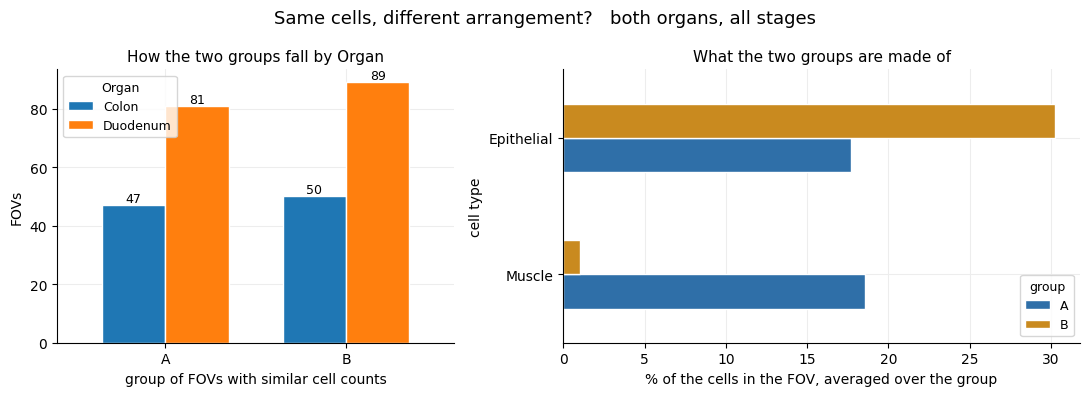

col_0,Colon,Duodenum
group,,
A,47,81
B,50,89


In [26]:
organ_groups, organ_table = composition_groups(
    data, all_fovs, 'Organ', save='abund_all_groups')
display(organ_table)


### 8b. Colon - do they line up with Control vs Severe?


saved summary_downloads\abund_cs_colon_groups.pdf


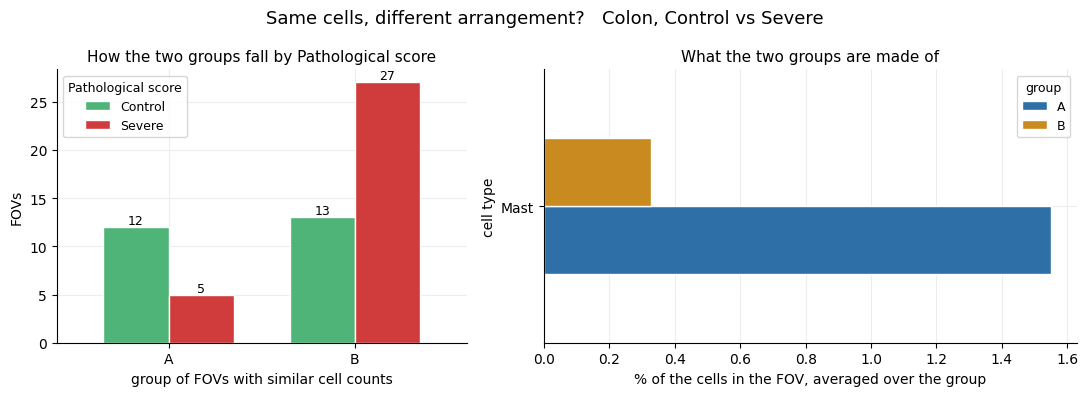

col_0,Control,Severe
group,,
A,12,5
B,13,27


In [27]:
colon_groups, colon_table = composition_groups(
    data, cs_colon, rs.SCORE_COL, save='abund_cs_colon_groups')
display(colon_table)


### 8c. Duodenum - do they line up with Control vs Severe?


saved summary_downloads\abund_cs_duodenum_groups.pdf


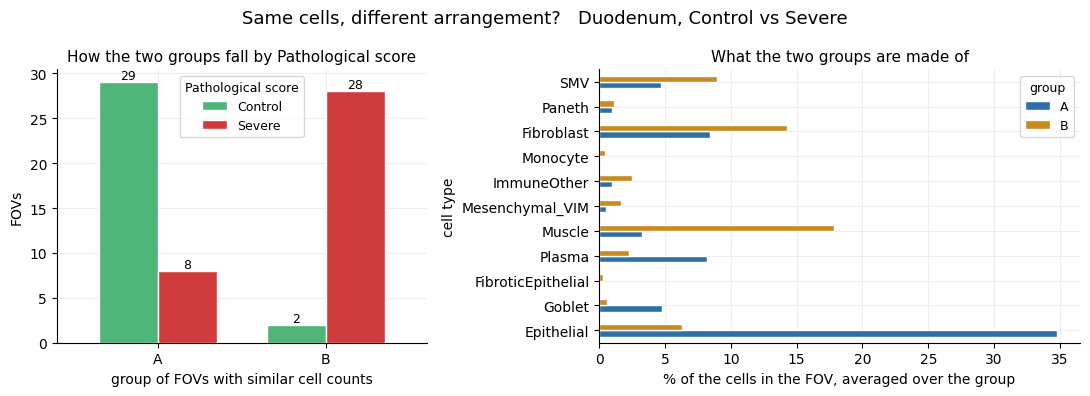

col_0,Control,Severe
group,,
A,29,8
B,2,28


In [28]:
duo_groups, duo_table = composition_groups(
    data, cs_duodenum, rs.SCORE_COL, save='abund_cs_duodenum_groups')
display(duo_table)


## The FOVs behind the groups

The bars show what each FOV is made of, the heatmap shows every cell type at
once. Both are sorted into the two groups, with the split we care about drawn
as a strip along the top.


saved summary_downloads\abund_all_group_bars.pdf


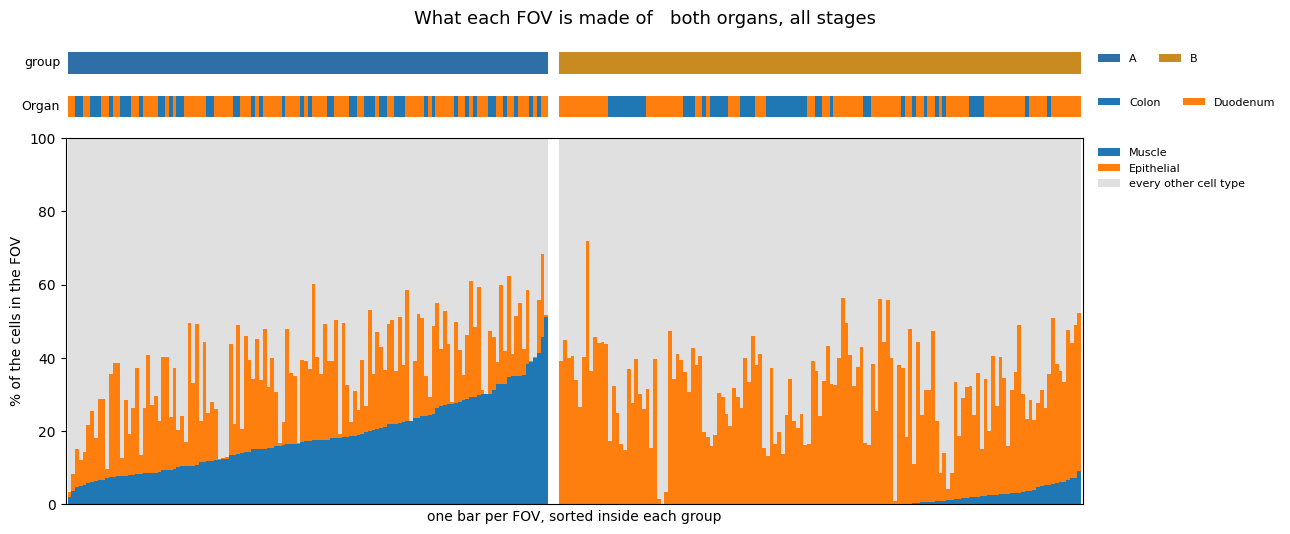

saved summary_downloads\abund_all_group_heatmap.pdf


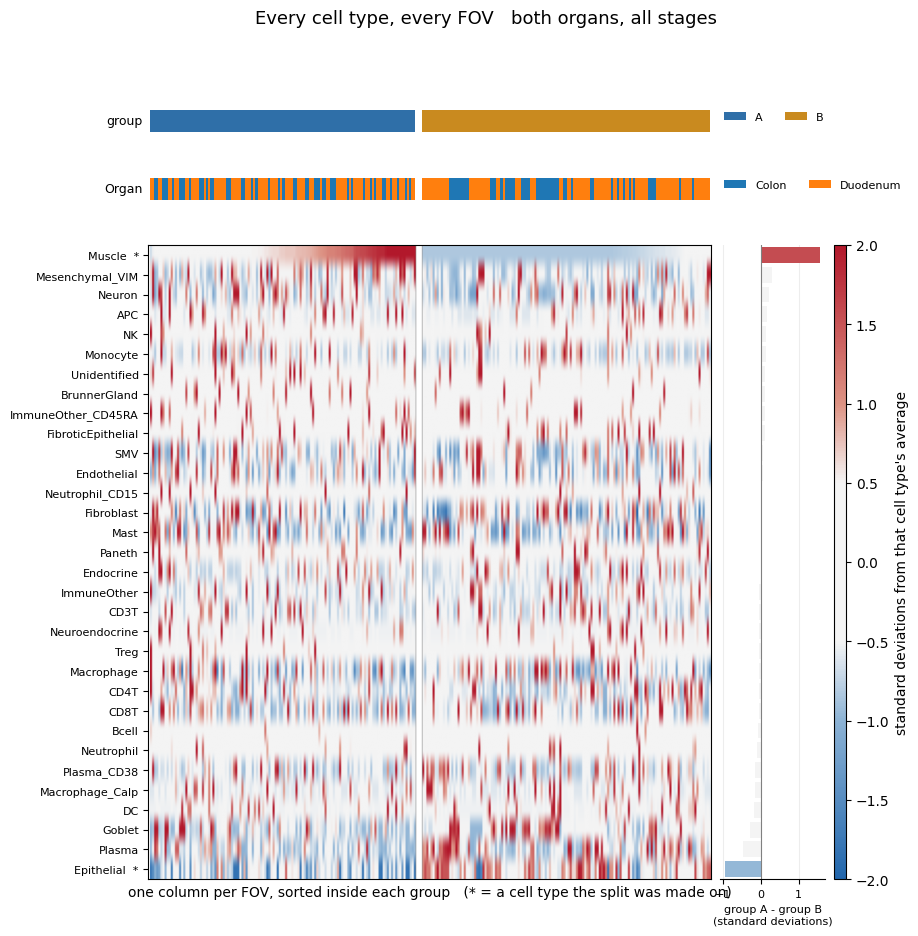

In [29]:
composition_figures(data, all_fovs, organ_groups, 'Organ', 'abund_all')


saved summary_downloads\abund_cs_colon_group_bars.pdf


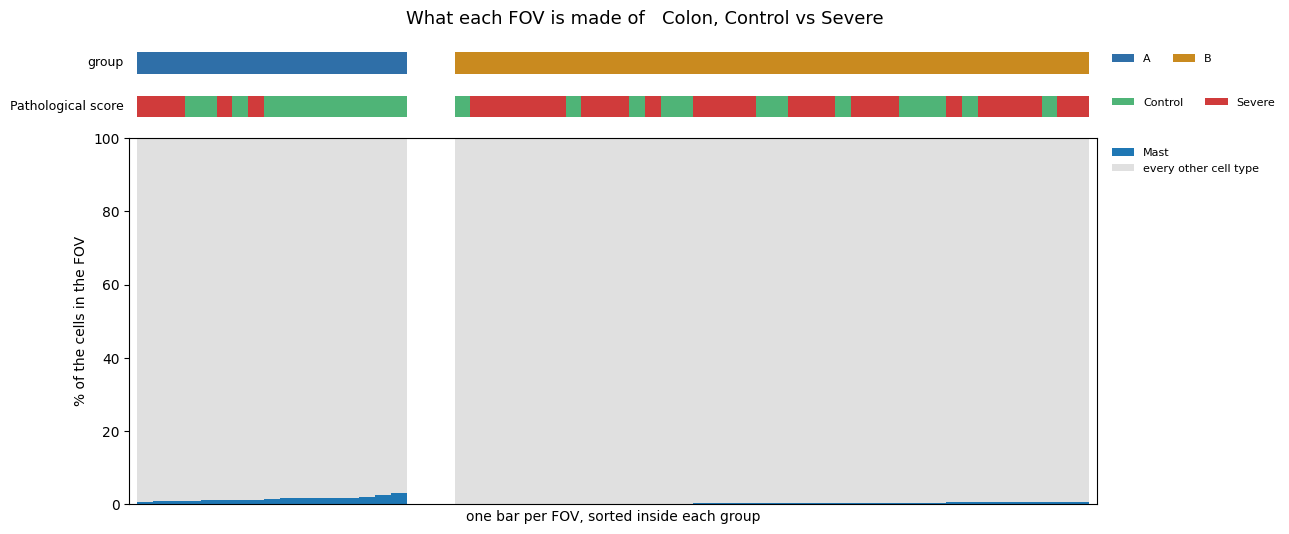

saved summary_downloads\abund_cs_colon_group_heatmap.pdf


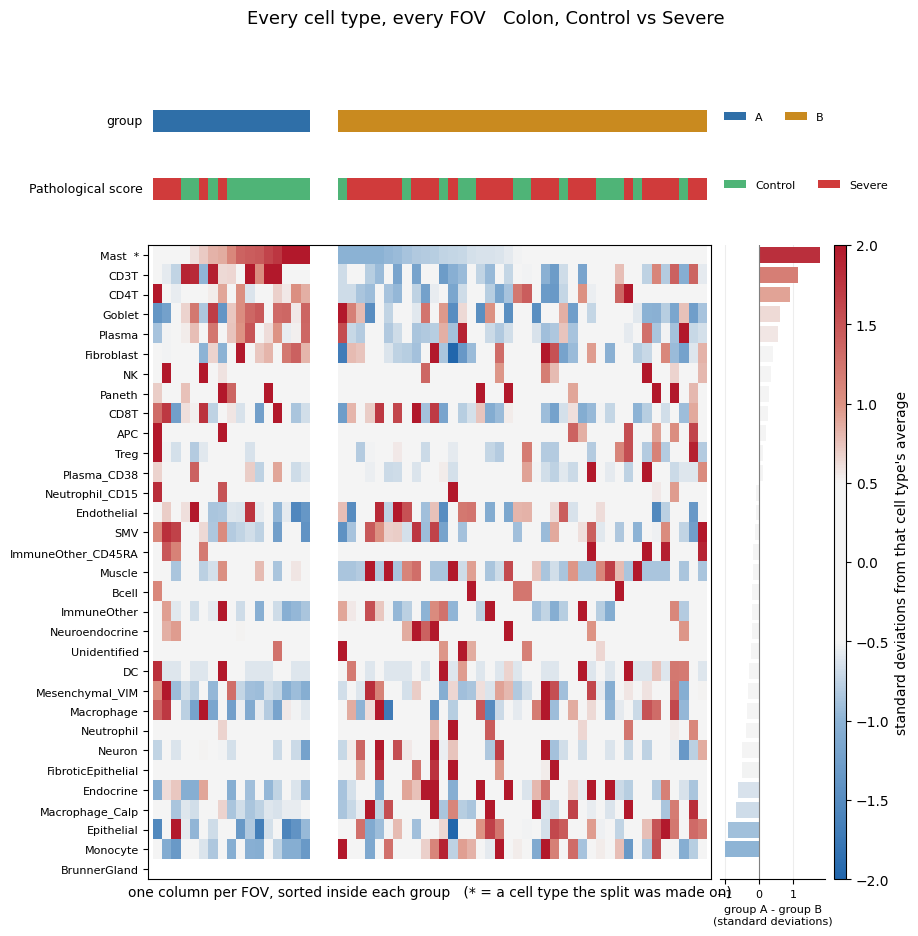

In [30]:
composition_figures(data, cs_colon, colon_groups, rs.SCORE_COL, 'abund_cs_colon')


saved summary_downloads\abund_cs_duodenum_group_bars.pdf


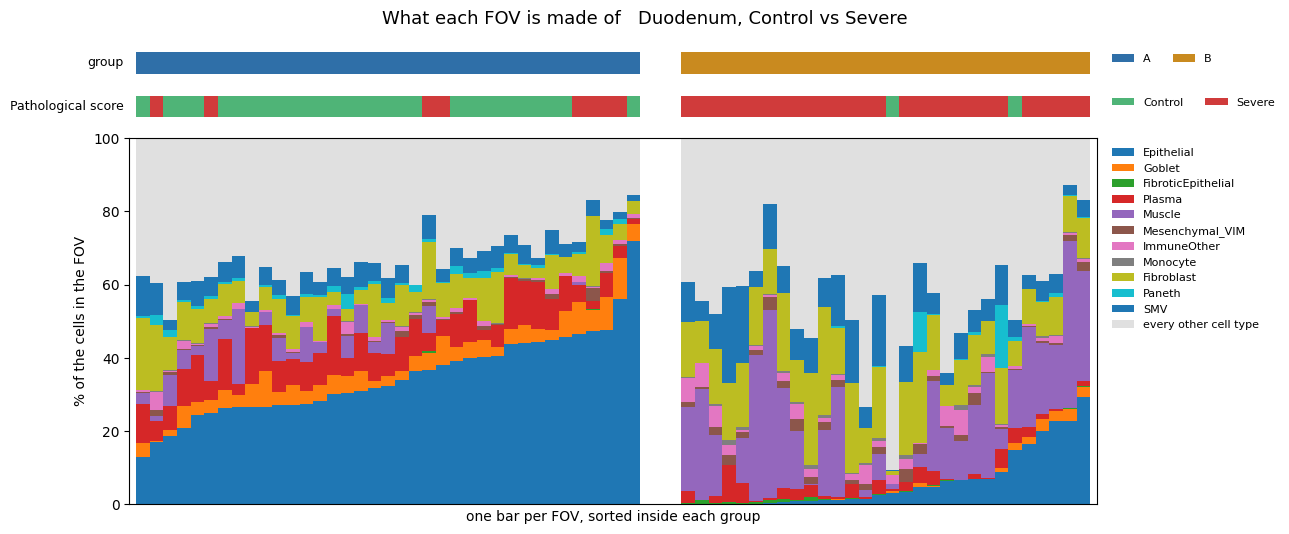

saved summary_downloads\abund_cs_duodenum_group_heatmap.pdf


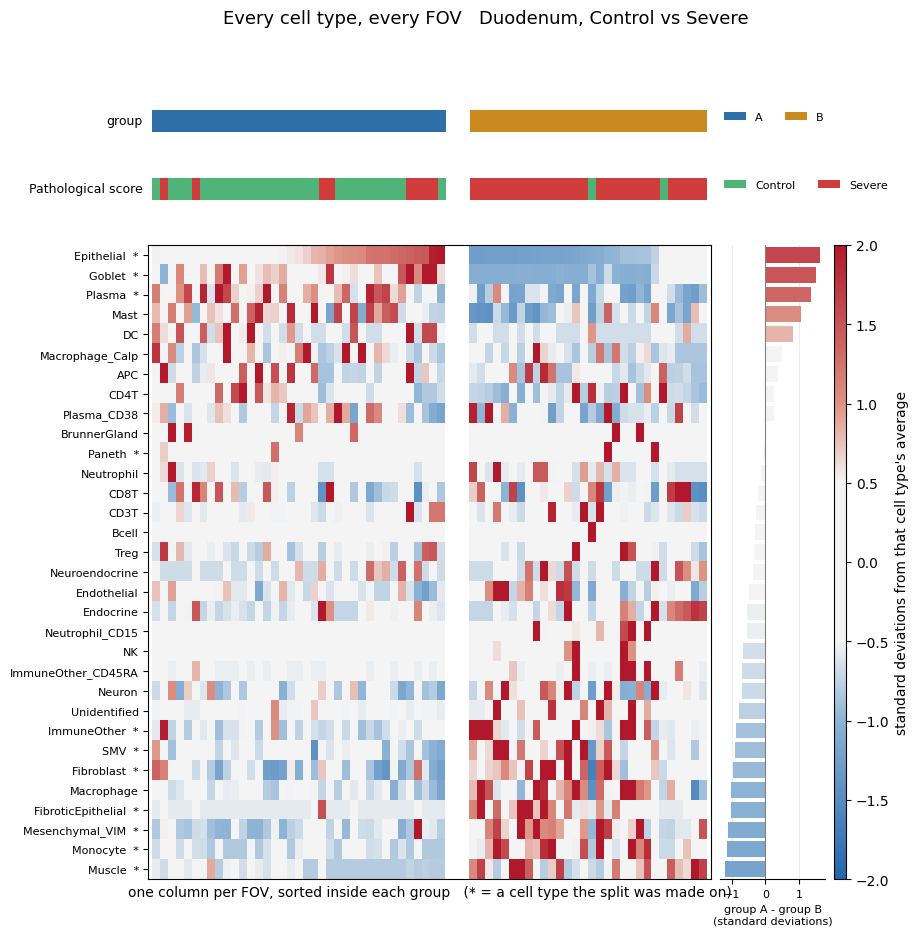

In [31]:
composition_figures(data, cs_duodenum, duo_groups, rs.SCORE_COL, 'abund_cs_duodenum')


## Do the rules work inside one makeup?

Take the group that holds both labels - its FOVs are made of much the same things -
and fit the rule PCA on those alone. If the labels still come apart there, the rules
carry something the cell counts do not. A group with one label only is skipped, and
it says why.

  group A: Colon 47, Duodenum 81
  group B: Colon 50, Duodenum 89
  group A is the most even, 47 against 81 - its PCA below
both organs, all stages: 128 FOVs x 97 columns  |  PC1 9.6%  PC2 6.9%
saved summary_downloads\abund_all_group_a_pca_organ.pdf


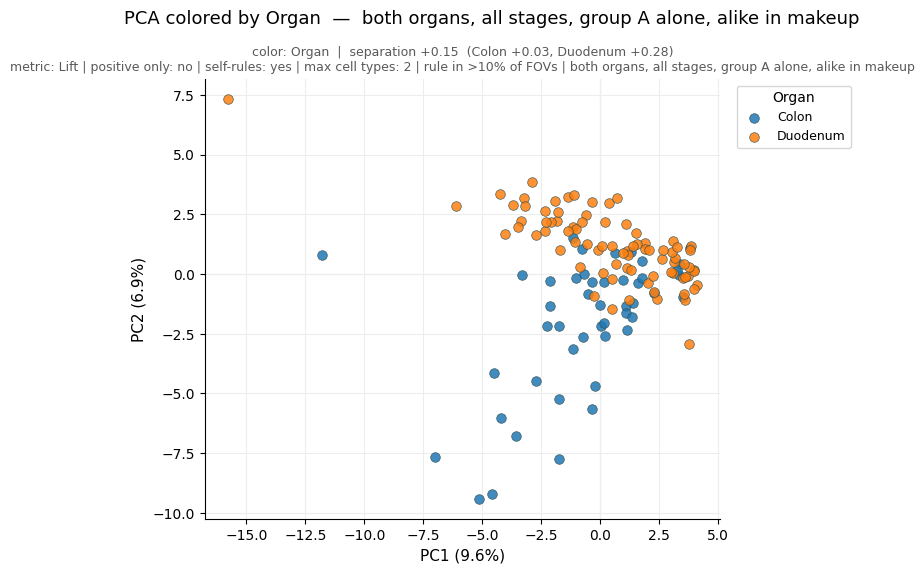

In [32]:
all_inside = rules_inside_one_makeup(data, all_fovs, organ_groups, 'Organ',
                                    'abund_all')

  group A: Control 12, Severe 5
  group B: Control 13, Severe 27
  group B is the most even, 13 against 27 - its PCA below
Colon, Control vs Severe: 40 FOVs x 81 columns  |  PC1 14.7%  PC2 11.4%
saved summary_downloads\abund_cs_colon_group_b_pca_pathological_score.pdf


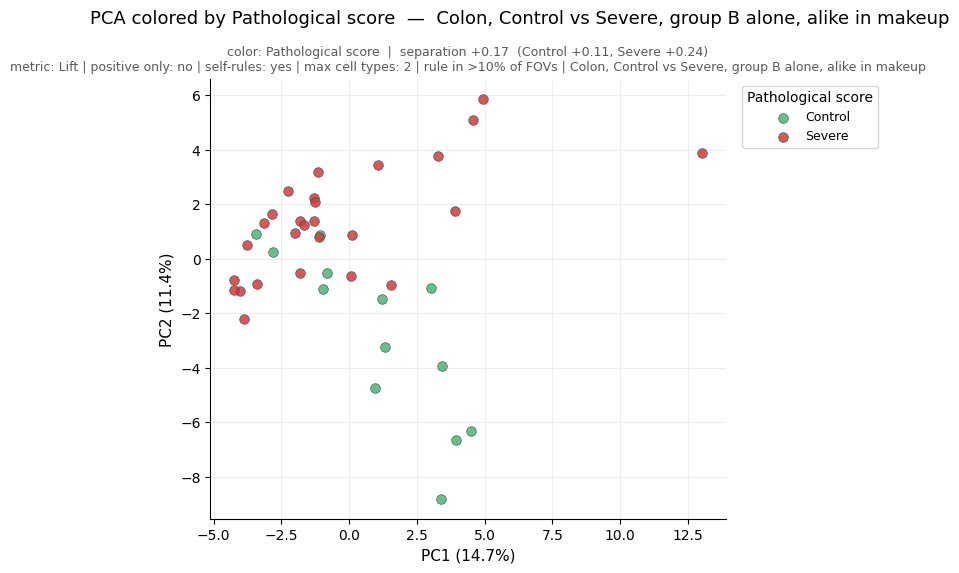

In [33]:
colon_inside = rules_inside_one_makeup(data, cs_colon, colon_groups, rs.SCORE_COL,
                                      'abund_cs_colon')

  group A: Control 29, Severe 8
  group B: Control 2, Severe 28
  group A is the most even, 8 against 29 - its PCA below
Duodenum, Control vs Severe: 37 FOVs x 70 columns  |  PC1 19.1%  PC2 8.7%
saved summary_downloads\abund_cs_duodenum_group_a_pca_pathological_score.pdf


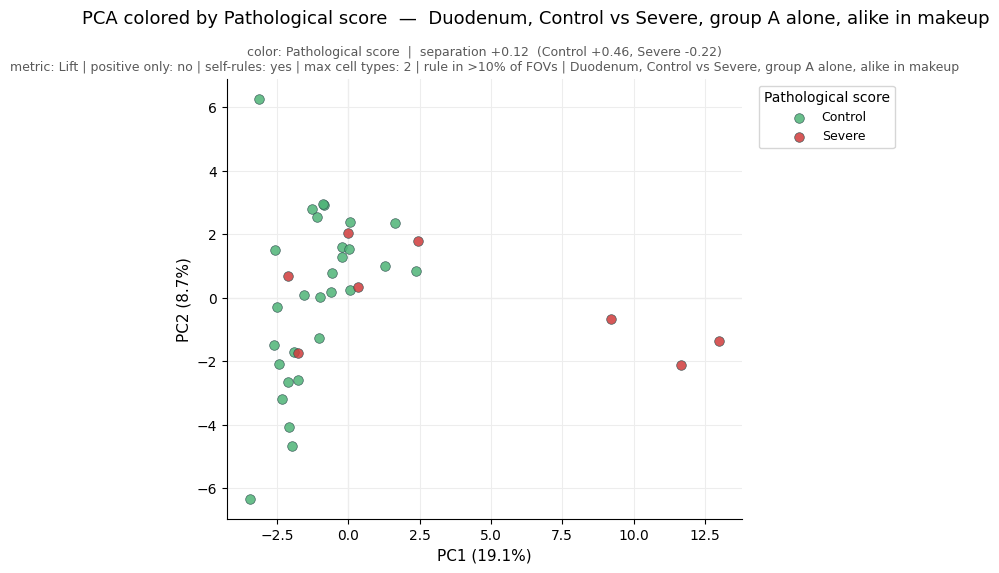

Duodenum, Control vs Severe, group A alone, alike in makeup: 3 of 37 FOVs sit more than 3x the usual 2.39 out from the middle
  GVHD_57_FOV_3              5.9x
  GVHD_57_FOV_4              5.4x
  GVHD_57_FOV_2              4.3x
Duodenum, Control vs Severe: 34 FOVs x 61 columns  |  PC1 11.2%  PC2 10.5%
saved summary_downloads\abund_cs_duodenum_group_a_trimmed_pca_pathological_score.pdf


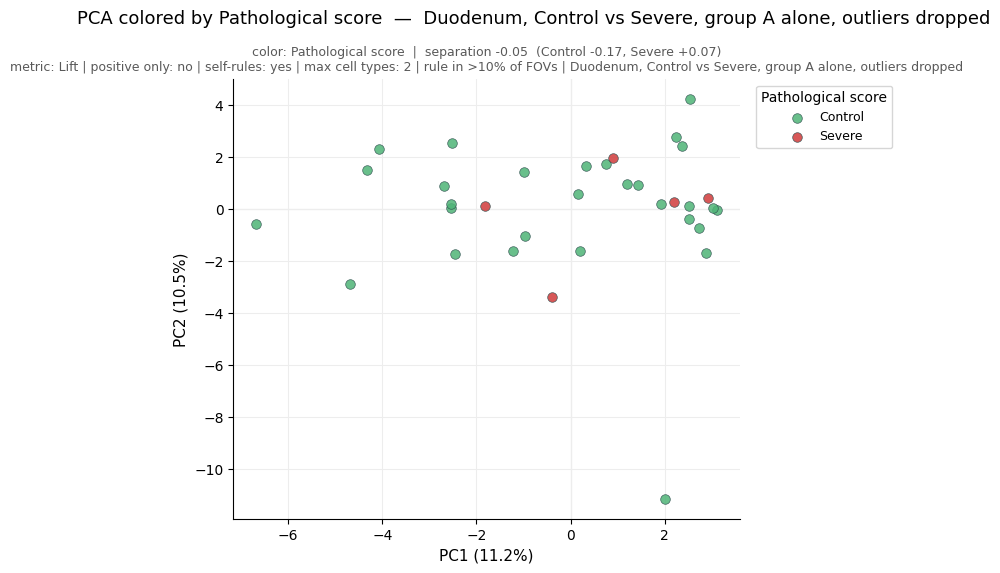

In [34]:
duo_inside = rules_inside_one_makeup(data, cs_duodenum, duo_groups, rs.SCORE_COL,
                                    'abund_cs_duodenum')

kept, _ = rs.outliers(duo_inside, k=3)                          # new cell
duo_inside_trimmed = rs.run(data, stages=cs_duodenum.stages, organs=cs_duodenum.organs,
                            fovs=kept, prefix='abund_cs_duodenum_group_a_trimmed',
                            diagnostics=False)
duo_inside_trimmed.built_from = 'group A alone, outliers dropped'
rs.scatter(duo_inside_trimmed, color_by=rs.SCORE_COL, save=True)

# 9. Which rules exist, or how strong they are?

Most of the rule matrix is the fill value - a typical rule fires in only a few
percent of the FOVs - so the PCA may be reading which rules exist rather than
how strong they are. Three matrices side by side settle it: the lift values, the
same rules as 1/0, and whether the FOV had enough of both cell types for the rule
to be found at all. The last one knows nothing about where the cells sit.


### 9a. All FOVs, by organ


both organs, all stages, which rules fired: 267 FOVs x 87 columns  |  PC1 11.2%  PC2 8.4%
both organs, all stages, which rules could fire: 267 FOVs x 86 columns  |  PC1 19.7%  PC2 15.7%
saved summary_downloads\abund_all_presence.pdf


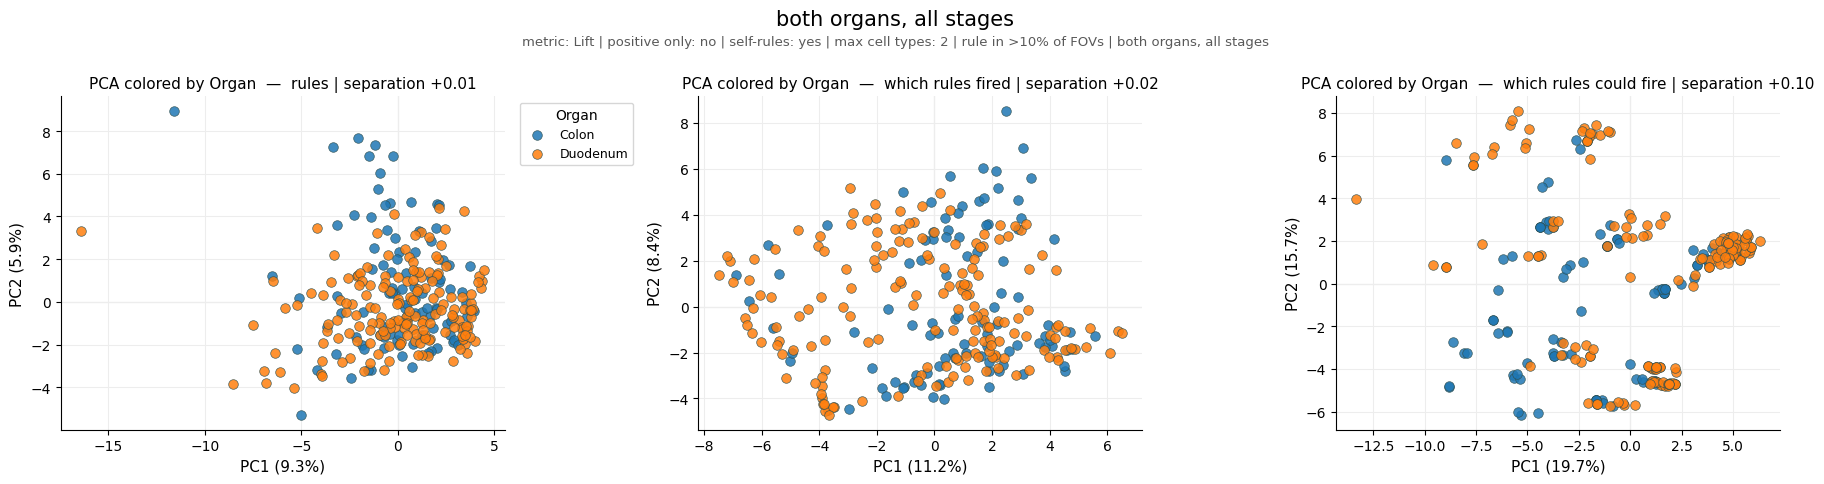

In [35]:
fired, possible = rs.presence_matrices(data, all_fovs)

rs.panel([[all_fovs, fired, possible]], color_by='Organ', save='abund_all_presence')


### 9b. Colon, Control vs Severe


Colon, Control vs Severe, which rules fired: 57 FOVs x 100 columns  |  PC1 14.4%  PC2 10.8%
Colon, Control vs Severe, which rules could fire: 57 FOVs x 90 columns  |  PC1 20.0%  PC2 17.7%
saved summary_downloads\abund_cs_colon_presence.pdf


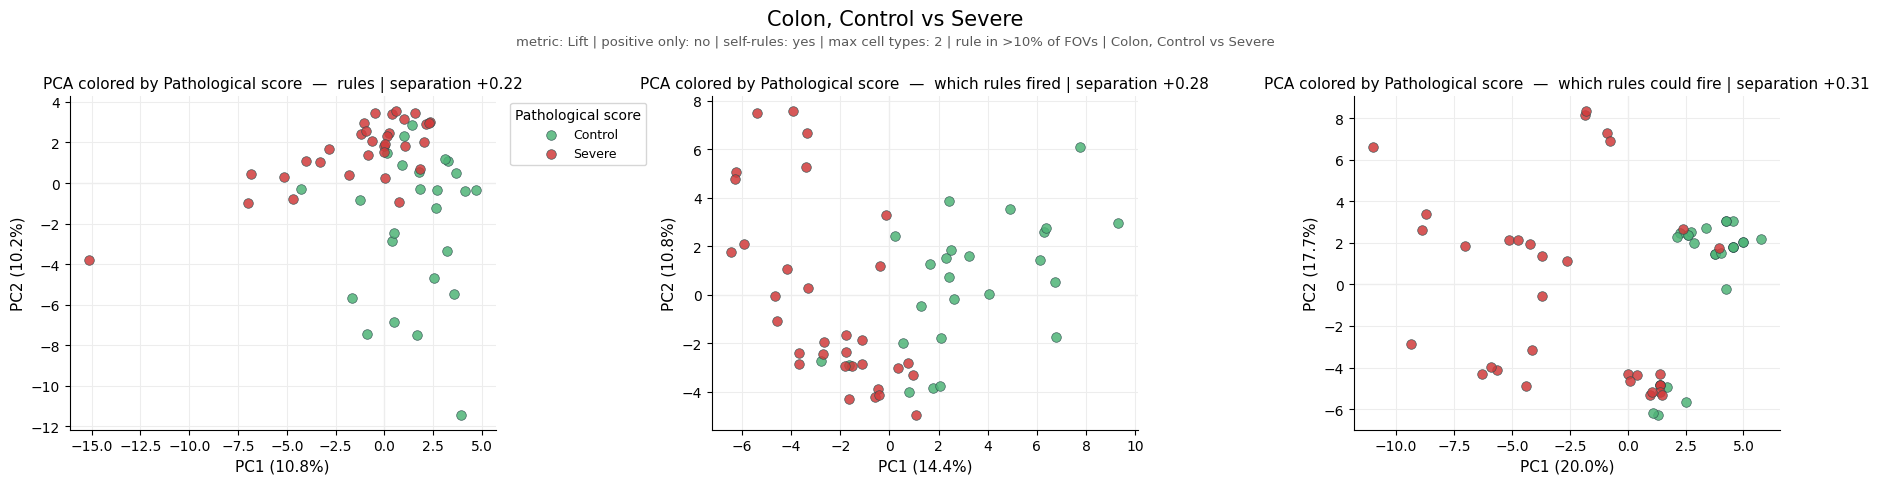

In [36]:
fired, possible = rs.presence_matrices(data, cs_colon)

rs.panel([[cs_colon, fired, possible]], save='abund_cs_colon_presence')


### 9c. Duodenum, Control vs Severe


Duodenum, Control vs Severe, which rules fired: 67 FOVs x 74 columns  |  PC1 18.8%  PC2 9.7%
Duodenum, Control vs Severe, which rules could fire: 67 FOVs x 73 columns  |  PC1 30.9%  PC2 19.6%
saved summary_downloads\abund_cs_duodenum_presence.pdf


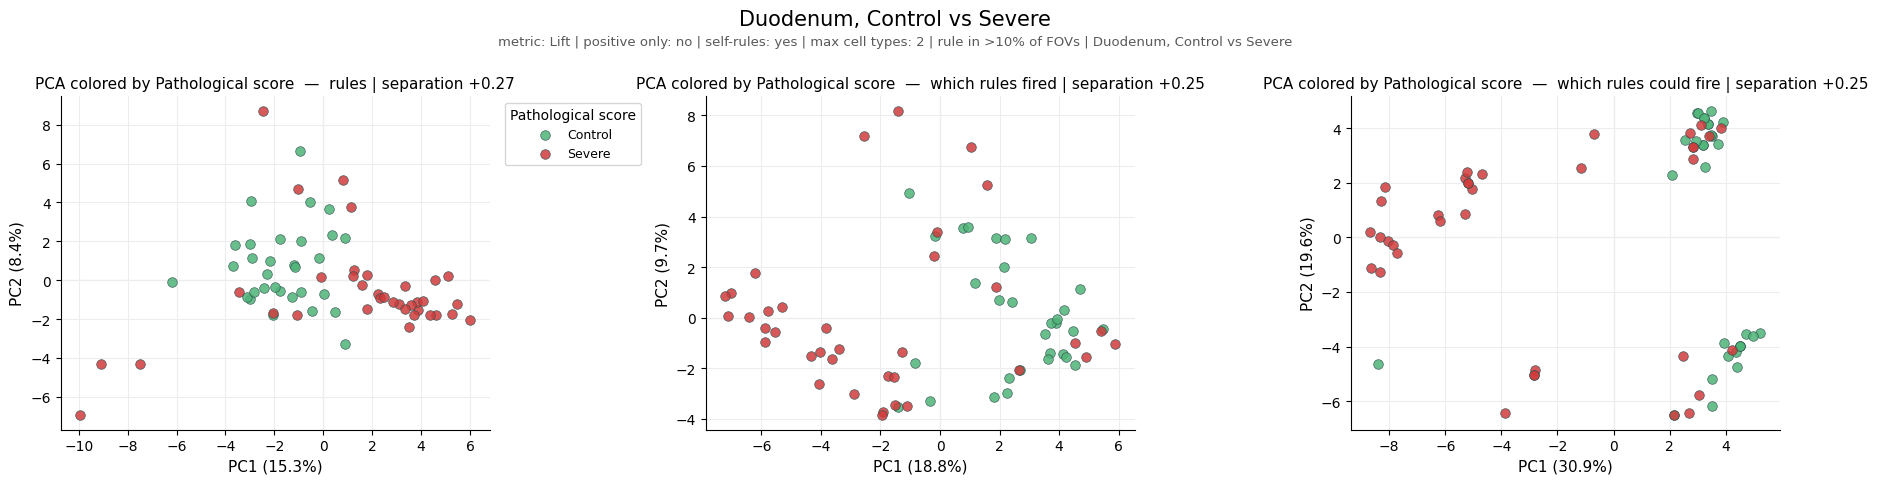

In [37]:
fired, possible = rs.presence_matrices(data, cs_duodenum)

rs.panel([[cs_duodenum, fired, possible]], save='abund_cs_duodenum_presence')
